In [ ]:
!pip install transformers torch pandas tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
pip install transformers datasets scikit-learn pandas


In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm


# Load data
df = pd.read_csv("Strictly_Balanced_Gold_Sentiment.csv")
le = LabelEncoder()
df["label"] = le.fit_transform(df["actual_sentiment"])  # 0=neg, 1=neutral, 2=pos

# Train/val split
train_df = df.sample(frac=0.8, random_state=42)
val_df = df.drop(train_df.index)

# Tokenizer & model
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Dataset class
class SentimentDataset(Dataset):
    def __init__(self, df):
        self.encodings = tokenizer(df['translated_text'].tolist(), truncation=True, padding=True, max_length=128)
        self.labels = df["label"].tolist()

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()} | {'labels': torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_df)
val_dataset = SentimentDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# Training loop
for epoch in range(5):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch+1} Loss: {total_loss:.2f}")

    # Evaluation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)
    print(f"📊 Epoch {epoch+1} Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1 Training: 100%|██████████| 12/12 [00:02<00:00,  4.00it/s]


Epoch 1 Loss: 13.46
📊 Epoch 1 Accuracy: 0.5000 | Macro F1: 0.3355


Epoch 2 Training: 100%|██████████| 12/12 [00:02<00:00,  4.17it/s]


Epoch 2 Loss: 13.03
📊 Epoch 2 Accuracy: 0.5909 | Macro F1: 0.4474


Epoch 3 Training: 100%|██████████| 12/12 [00:02<00:00,  4.13it/s]


Epoch 3 Loss: 12.43
📊 Epoch 3 Accuracy: 0.6364 | Macro F1: 0.4819


Epoch 4 Training: 100%|██████████| 12/12 [00:03<00:00,  3.76it/s]


Epoch 4 Loss: 12.29
📊 Epoch 4 Accuracy: 0.6364 | Macro F1: 0.4819


Epoch 5 Training: 100%|██████████| 12/12 [00:03<00:00,  3.56it/s]


Epoch 5 Loss: 12.10
📊 Epoch 5 Accuracy: 0.5909 | Macro F1: 0.5667


In [ ]:
# Save model and tokenizer to local Colab directory
output_dir = "./xlmr_sentiment_finetuned"
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print("✅ Model and tokenizer saved to", output_dir)

✅ Model and tokenizer saved to ./xlmr_sentiment_finetuned


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
import pandas as pd
import torch

# Load fine-tuned model
model_path = "./xlmr_sentiment_finetuned"
model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)
model.eval()

# Labels (same as in training)
labels = ["negative", "neutral", "positive"]

# Predict function
def predict_sentiment(text):
    tokens = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128)
    with torch.no_grad():
        outputs = model(**tokens)
    probs = softmax(outputs.logits, dim=1)
    pred_class = torch.argmax(probs).item()
    return labels[pred_class]

# Load your test dataset (make sure it has 'translated_text')
df_test = pd.read_csv("Strictly_Balanced_Gold_Sentiment.csv")  # change path if needed
df_test["predicted_sentiment"] = df_test["translated_text"].apply(predict_sentiment)

# Save results
df_test.to_csv("xlmr_predictions.csv", index=False)
print("✅ Predictions saved as xlmr_predictions.csv")


✅ Predictions saved as xlmr_predictions.csv


🔍 Classification Report:

              precision    recall  f1-score   support

    negative       0.44      0.92      0.59        37
     neutral       0.67      0.11      0.19        37
    positive       0.70      0.51      0.59        37

    accuracy                           0.51       111
   macro avg       0.60      0.51      0.46       111
weighted avg       0.60      0.51      0.46       111



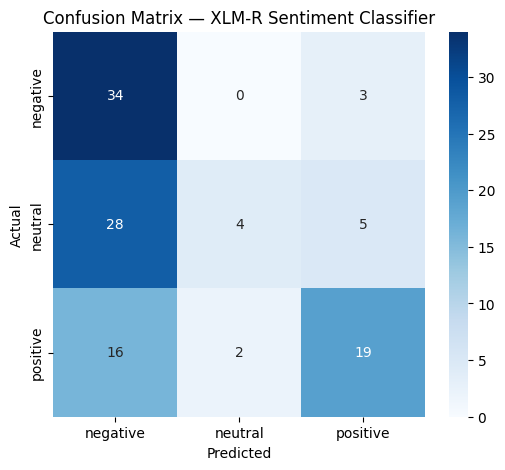

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Make sure your dataframe has these two columns:
# - 'actual_sentiment'
# - 'predicted_sentiment'

# Optional: sort classes for consistency
labels = ["negative", "neutral", "positive"]

# 1. Classification Report (F1, precision, recall)
print("🔍 Classification Report:\n")
print(classification_report(df_test["actual_sentiment"], df_test["predicted_sentiment"], labels=labels))

# 2. Confusion Matrix
cm = confusion_matrix(df_test["actual_sentiment"], df_test["predicted_sentiment"], labels=labels)

# 3. Plot it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — XLM-R Sentiment Classifier")
plt.show()


In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
import torch
from tqdm import tqdm

# Load data
df = pd.read_csv("reddit_tariffs_multilingual_translated_1.csv")

# Load model
model_name = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()
labels = ['negative', 'neutral', 'positive']

# Prediction function
def predict_sentiment(text):
    try:
        tokens = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512)
        with torch.no_grad():
            output = model(**tokens)
        probs = softmax(output.logits, dim=1)
        return labels[torch.argmax(probs)]
    except:
        return None

# Run sentiment analysis
tqdm.pandas()
df['sentiment'] = df['translated_text'].progress_apply(predict_sentiment)
df = df.dropna(subset=['sentiment'])

# Save result
df.to_csv("reddit_sentiment_labeled.csv", index=False)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
  0%|          | 0/1914 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

100%|██████████| 1914/1914 [06:24<00:00,  4.97it/s]


In [ ]:
df.head(50)

,date,text,translated_text,language,query,subreddit,sentiment
0,2024-11-01,Switzerland wants more trade with China despit...,Switzerland wants more trade with China despit...,en,trade,china,neutral
1,2024-11-02,Historia de la política mexicana \nQué libros ...,History of Mexican politics\nWhat books can yo...,es,política,mexico,neutral
2,2024-11-02,Do people trade in cash or credit?\nI've heard...,Do people trade in cash or credit?\nI've heard...,en,trade,AskEconomics,neutral
3,2024-11-02,"Cuál he sido el momento más raro, bizarro, chu...","What has been the weird moment, Bizarro, Chusc...",es,política,mexico,negative
4,2024-11-02,Donald Trump’s proposed tariffs would damage t...,Donald Trump’s proposed tariffs would damage t...,en,tariff,economics,negative
5,2024-11-04,Trump or Harris: Either Way Expect a Transatla...,Trump or Harris: Either Way Expect a Transatla...,en,trade,geopolitics,neutral
6,2024-11-05,What populists don't understand about tariffs ...,What populists don't understand about tariffs ...,en,tariff,economics,negative
7,2024-11-06,"Immigration, Trade, Military: How Trump 2.0 Co...","Immigration, Trade, Military: How Trump 2.0 Co...",en,trade,india,neutral
8,2024-11-06,Trump Presidency Predictions for China\nNow th...,Trump Presidency Predictions for China\nNow th...,en,tariff,china,negative
9,2024-11-06,Asia braces for steep China tariffs and securi...,Asia braces for steep China tariffs and securi...,en,tariff,economics,negative


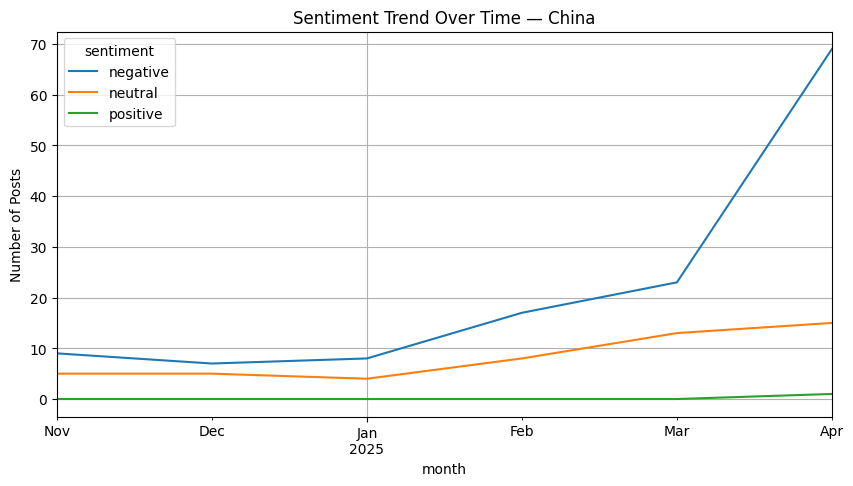

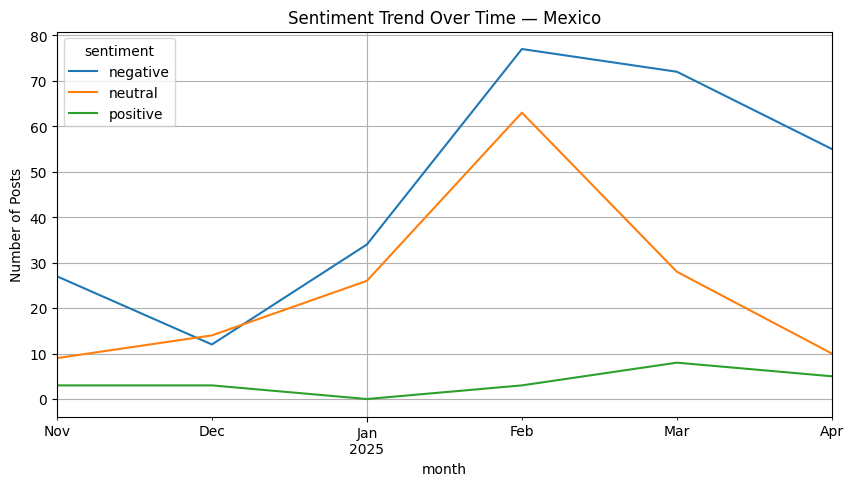

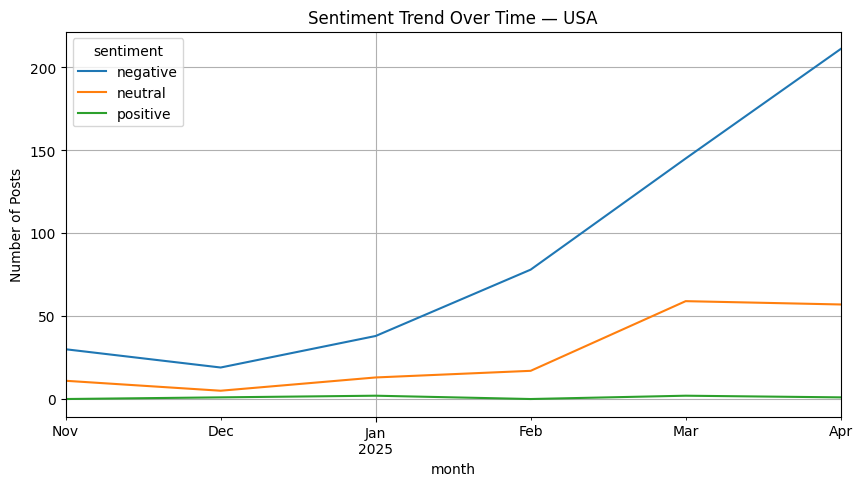

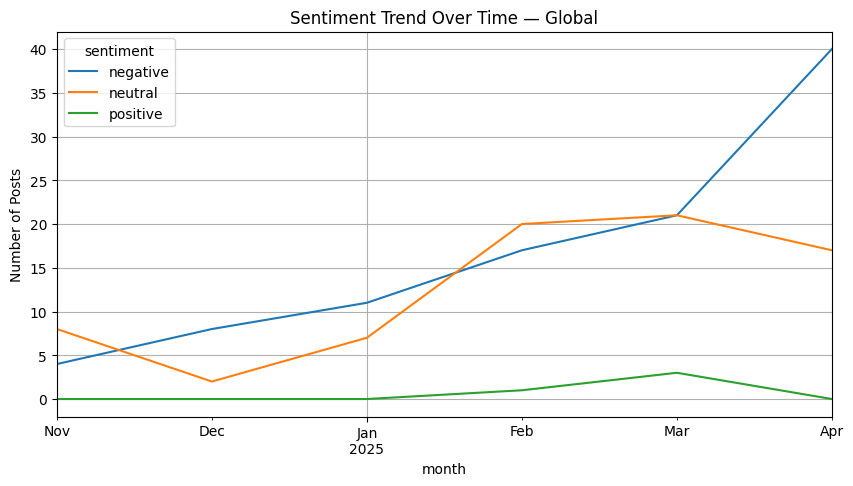

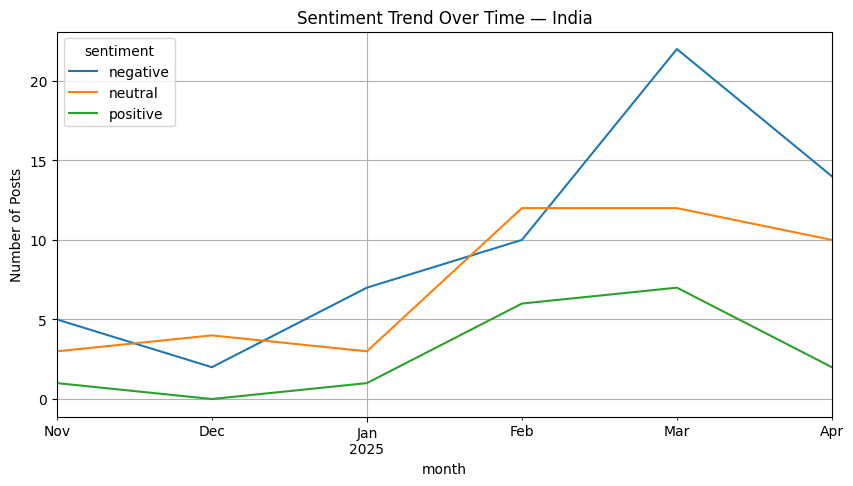

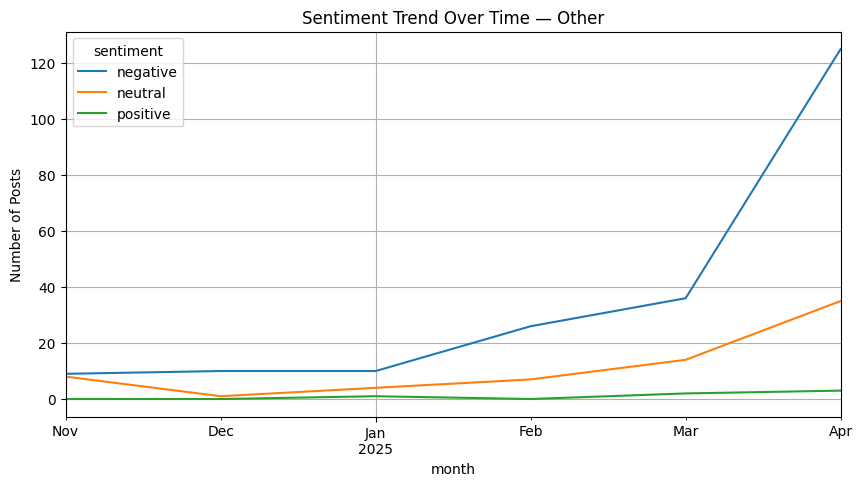

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the labeled dataset
df = pd.read_csv("reddit_sentiment_labeled.csv")

# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# Map subreddits to country
subreddit_to_country = {
    "india": "India",
    "mexico": "Mexico",
    "china": "China",
    "AskEconomics": "USA",
    "economics": "USA",
    "geopolitics": "Global",
    "Sino": "China",
    "canada": "Canada"
}

df['country'] = df['subreddit'].map(subreddit_to_country).fillna("Other")

# Group by month, sentiment, and country
df['month'] = df['date'].dt.to_period("M")
grouped = df.groupby(['month', 'country', 'sentiment']).size().unstack(fill_value=0).reset_index()

# Plot sentiment trend for each country
countries = df['country'].unique()
for country in countries:
    country_data = grouped[grouped['country'] == country].set_index('month')[['negative', 'neutral', 'positive']]
    country_data.plot(figsize=(10, 5), title=f"Sentiment Trend Over Time — {country}")
    plt.ylabel("Number of Posts")
    plt.grid(True)
    plt.show()


Evaluation metric(F1 Score)

In [4]:
import pandas as pd
from sklearn.metrics import classification_report, f1_score

# Load the prediction file
df = pd.read_csv("xlmr_predictions.csv")

# Check required columns
assert 'actual_sentiment' in df.columns and 'predicted_sentiment' in df.columns, \
    "CSV must have 'sentiment' and 'predicted_sentiment' columns."

# Compute scores
f1_macro = f1_score(df['actual_sentiment'], df['predicted_sentiment'], average='macro')
f1_micro = f1_score(df['actual_sentiment'], df['predicted_sentiment'], average='micro')
report = classification_report(df['actual_sentiment'], df['predicted_sentiment'])

# Print results
print("✅ F1 Macro Score:", round(f1_macro, 3))
print("✅ F1 Micro Score:", round(f1_micro, 3))
print("📋 Classification Report:\n", report)


✅ F1 Macro Score: 0.606
✅ F1 Micro Score: 0.631
📋 Classification Report:
               precision    recall  f1-score   support

    negative       0.78      0.68      0.72        37
     neutral       0.65      0.30      0.41        37
    positive       0.55      0.92      0.69        37

    accuracy                           0.63       111
   macro avg       0.66      0.63      0.61       111
weighted avg       0.66      0.63      0.61       111






####Topic modelling - INDIA

> we have chosen one country and tried to showcase all the high frequency words using BERTTopic and LDA






In [ ]:
!pip install bertopic sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 805.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
!pip install pandas spacy nltk gensim scikit-learn networkx matplotlib seaborn vaderSentiment pyLDAvis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 71.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
 

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 80.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


FINAL TOPIC MODELLING- INDIA

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



📌 Top Influencers per Topic:

🗂 India Economic Disruption
   Tariff: 27 mentions
   Export: 14 mentions
   Donald Trump: 10 mentions
   Import: 8 mentions
   Rbi: 6 mentions

🗂 India Export Policy
   Tariff: 38 mentions
   Export: 15 mentions
   Donald Trump: 11 mentions
   Rbi: 5 mentions
   Raghav Chadha: 5 mentions

🗂 Trade Diplomacy & Leadership
   Tariff: 61 mentions
   Export: 38 mentions
   Donald Trump: 24 mentions
   Import: 20 mentions
   Trade Deficit: 8 mentions

🗂 Trump’s Tariff Legacy
   Tariff: 85 mentions
   Donald Trump: 62 mentions
   Export: 38 mentions
   Import: 36 mentions
   White House: 6 mentions

🗂 US Tariff Market Impact
   Tariff: 29 mentions
   Export: 12 mentions
   Import: 11 mentions
   Donald Trump: 7 mentions
   White House: 4 mentions
✅ Saved cleaned + enriched file: 'new_NER.csv'


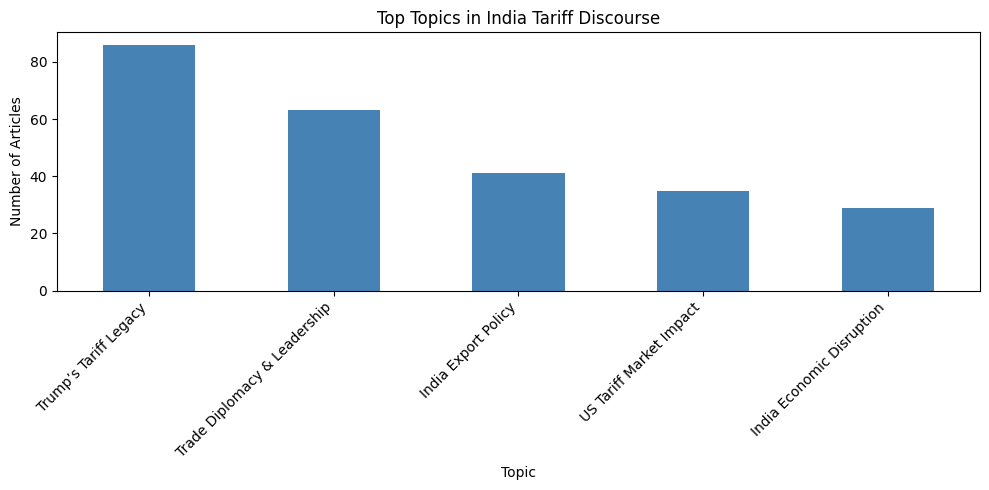

<ipython-input-22-3b6ec1b7ab99>:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_sentiment.values, y=avg_sentiment.index, palette="coolwarm")


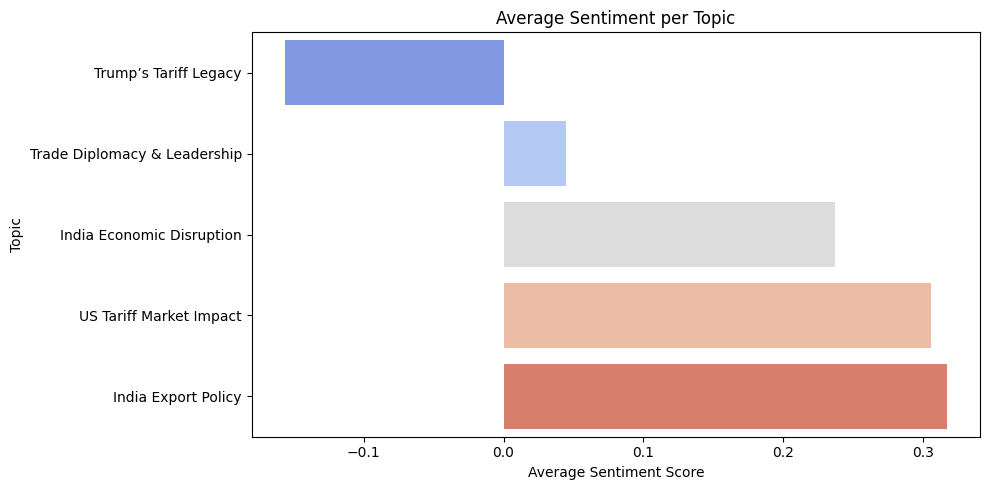

<ipython-input-22-3b6ec1b7ab99>:168: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = pd.to_datetime(df['publish_date']).dt.to_period("W").apply(lambda r: r.start_time)


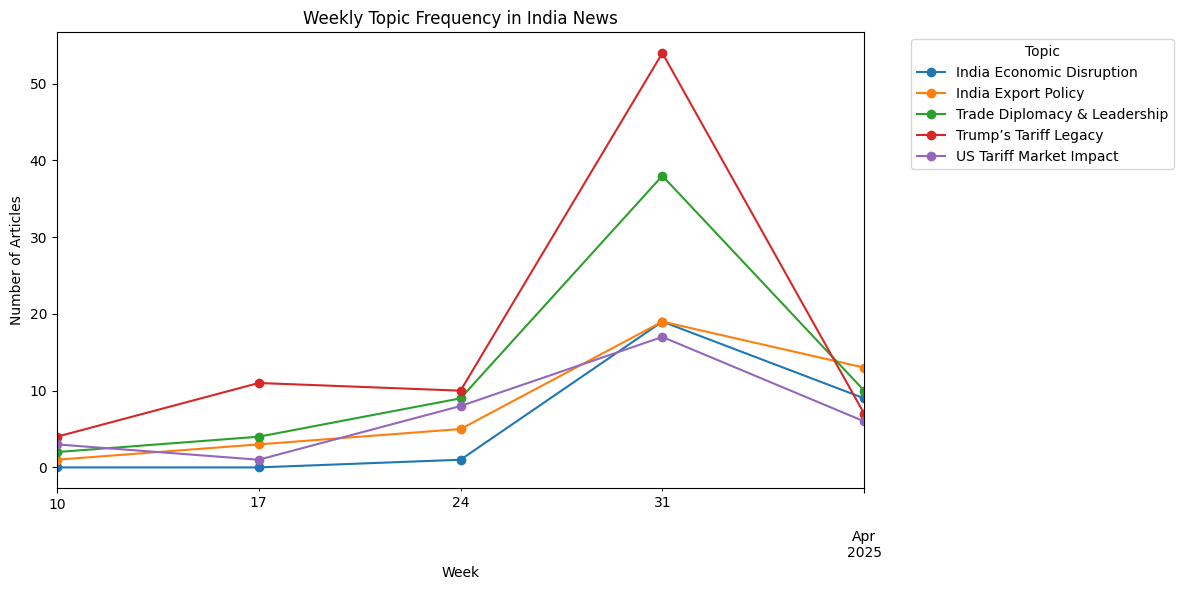

In [ ]:
import pandas as pd
import re
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import gensim
from gensim import corpora
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pyLDAvis.gensim_models
from collections import Counter
from itertools import combinations

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
# Download the necessary NLTK resource
nltk.download('punkt_tab')


# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Initialize sentiment analyzer
sid = SentimentIntensityAnalyzer()

# Load dataset
df = pd.read_csv("India_sector_news_articles.csv")

# 1. Preprocess text
def clean_text(text):
    # Convert to string if not already
    if not isinstance(text, str):
        text = str(text)
    # Remove HTML tags, special characters, and metadata
    text = re.sub(r'<.*?>|\[.*?\]|[^a-zA-Z\s]', '', text)
    text = text.lower()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# 🧹 Clean + combine and preprocess only India-relevant articles
df = df[
    df['title'].str.contains("India", case=False, na=False) |
    df['description'].str.contains("India", case=False, na=False) |
    df['content'].str.contains("India", case=False, na=False)
].copy()

df['cleaned_text'] = (df['title'].astype(str) + ' ' + df['description'].astype(str) + ' ' + df['content'].astype(str)).apply(clean_text)

# Step 2: Clean NER Entities + Normalize Names
def is_valid_entity(ent):
    if len(ent.split()) > 4:
        return False
    blacklist = ["href", "window", "http", "cookie", "terms", "login", "march", "april"]
    return not any(x in ent.lower() for x in blacklist)

manual_mapping = {
    "trump": "Donald Trump",
    "donald trump": "Donald Trump",
    "donald trump's": "Donald Trump",
    "rbi": "RBI",
    "reserve bank of india": "RBI",
    "pm modi": "Narendra Modi",
    "narendra modi": "Narendra Modi",
}

def normalize(ent):
    ent = ent.lower().strip().replace("’s", "").replace("’", "").replace("'", "")
    return manual_mapping.get(ent, ent.title())

def extract_entities(text):
    doc = nlp(text)
    return [normalize(ent.text) for ent in doc.ents if ent.label_ in ['PERSON', 'ORG'] and is_valid_entity(ent.text)]

df['entities'] = df['cleaned_text'].apply(extract_entities)

# Step 3: Add economic terms
economic_terms = [
    "tariff", "inflation", "export", "import", "policy", "reform",
    "gst", "subsidy", "gdp", "trade deficit", "rupee", "rbi", "interest rate"
]
def match_econ_terms(text):
    text = text.lower()
    return [term.title() for term in economic_terms if term in text]

df['econ_terms'] = df['cleaned_text'].apply(match_econ_terms)
df['combined_influencers'] = df.apply(lambda row: row['entities'] + row['econ_terms'], axis=1)

# Step 4: Topic Modeling + Labeling
texts = [text.split() for text in df['cleaned_text']]
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]
lda_model = gensim.models.ldamodel.LdaModel(corpus, num_topics=5, id2word=dictionary, passes=10)

# Assign topics and probabilities
df['topic'] = [lda_model[corpus[i]][0][0] for i in range(len(corpus))]
df['topic_probability'] = [lda_model[corpus[i]][0][1] for i in range(len(corpus))]

# Apply custom topic labels based on output
topic_labels = {
    0: "US Tariff Market Impact",
    1: "India Export Policy",
    2: "India Economic Disruption",
    3: "Trade Diplomacy & Leadership",
    4: "Trump’s Tariff Legacy"
}
df['topic_label'] = df['topic'].map(topic_labels)

# Step 5: Sentiment
df['sentiment'] = df['cleaned_text'].apply(get_sentiment)

# Step 6: Top Influencers Per Topic
from collections import defaultdict, Counter
from itertools import chain

top_influencers_by_topic = defaultdict(list)
grouped = df.groupby('topic_label')

for topic, group in grouped:
    all_ents = list(chain.from_iterable(group['combined_influencers']))
    top = Counter(all_ents).most_common(5)
    top_influencers_by_topic[topic] = top

# Print them
print("\n📌 Top Influencers per Topic:")
for topic, items in top_influencers_by_topic.items():
    print(f"\n🗂 {topic}")
    for name, count in items:
        print(f"   {name}: {count} mentions")

# Step 7: Save + plot
df.to_csv("new_NER.csv", index=False)
print("✅ Saved cleaned + enriched file: 'new_NER.csv'")

plt.figure(figsize=(10, 5))
df['topic_label'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Top Topics in India Tariff Discourse")
plt.xlabel("Topic")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#avg sentiment per topic
plt.figure(figsize=(10, 5))
avg_sentiment = df.groupby('topic_label')['sentiment'].mean().sort_values()
sns.barplot(x=avg_sentiment.values, y=avg_sentiment.index, palette="coolwarm")
plt.title("Average Sentiment per Topic")
plt.xlabel("Average Sentiment Score")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

#topic trnds
df['week'] = pd.to_datetime(df['publish_date']).dt.to_period("W").apply(lambda r: r.start_time)
weekly_trends = df.groupby(['week', 'topic_label']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
weekly_trends.plot(ax=plt.gca(), marker='o')
plt.title("Weekly Topic Frequency in India News")
plt.xlabel("Week")
plt.ylabel("Number of Articles")
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



✅ Top Influencers in India-Focused Articles (NER + Economic Concepts):
tariff: 198 mentions
Donald Trump: 72 mentions
export: 55 mentions
import: 47 mentions
Trump: 25 mentions
Donald Trumps: 15 mentions
Sensex, Nifty: 7 mentions
BSE: 7 mentions
policy: 7 mentions
RBI: 7 mentions
BTA: 6 mentions
rbi: 6 mentions
gdp: 5 mentions
BSE Sensex: 4 mentions
Reuters: 4 mentions

✅ Saved cleaned dataset to 'filtered_india_articles_with_influencers.csv'


<ipython-input-14-ae4c80966b1f>:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_counts), y=list(top_names), palette="viridis")


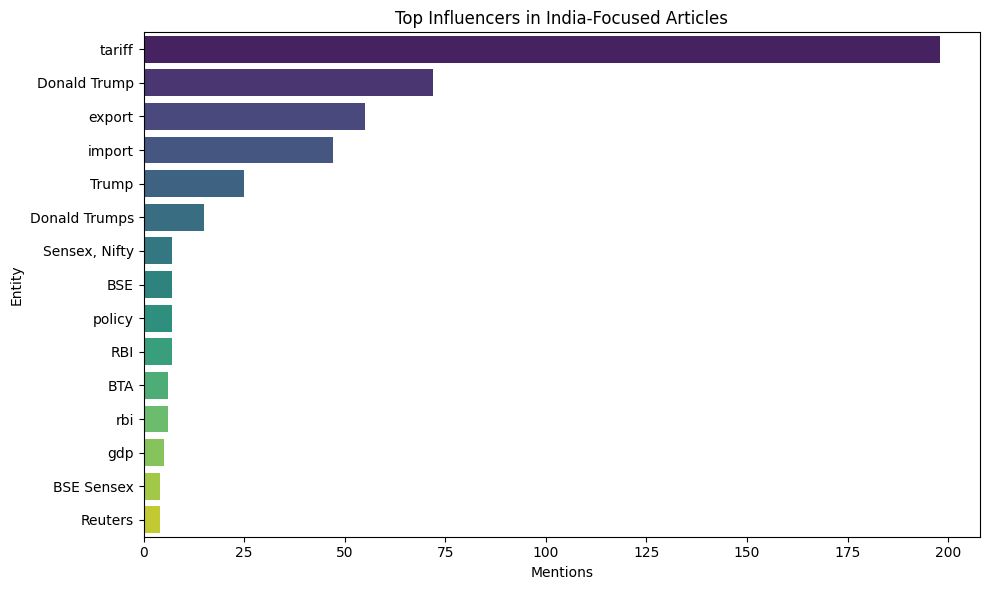

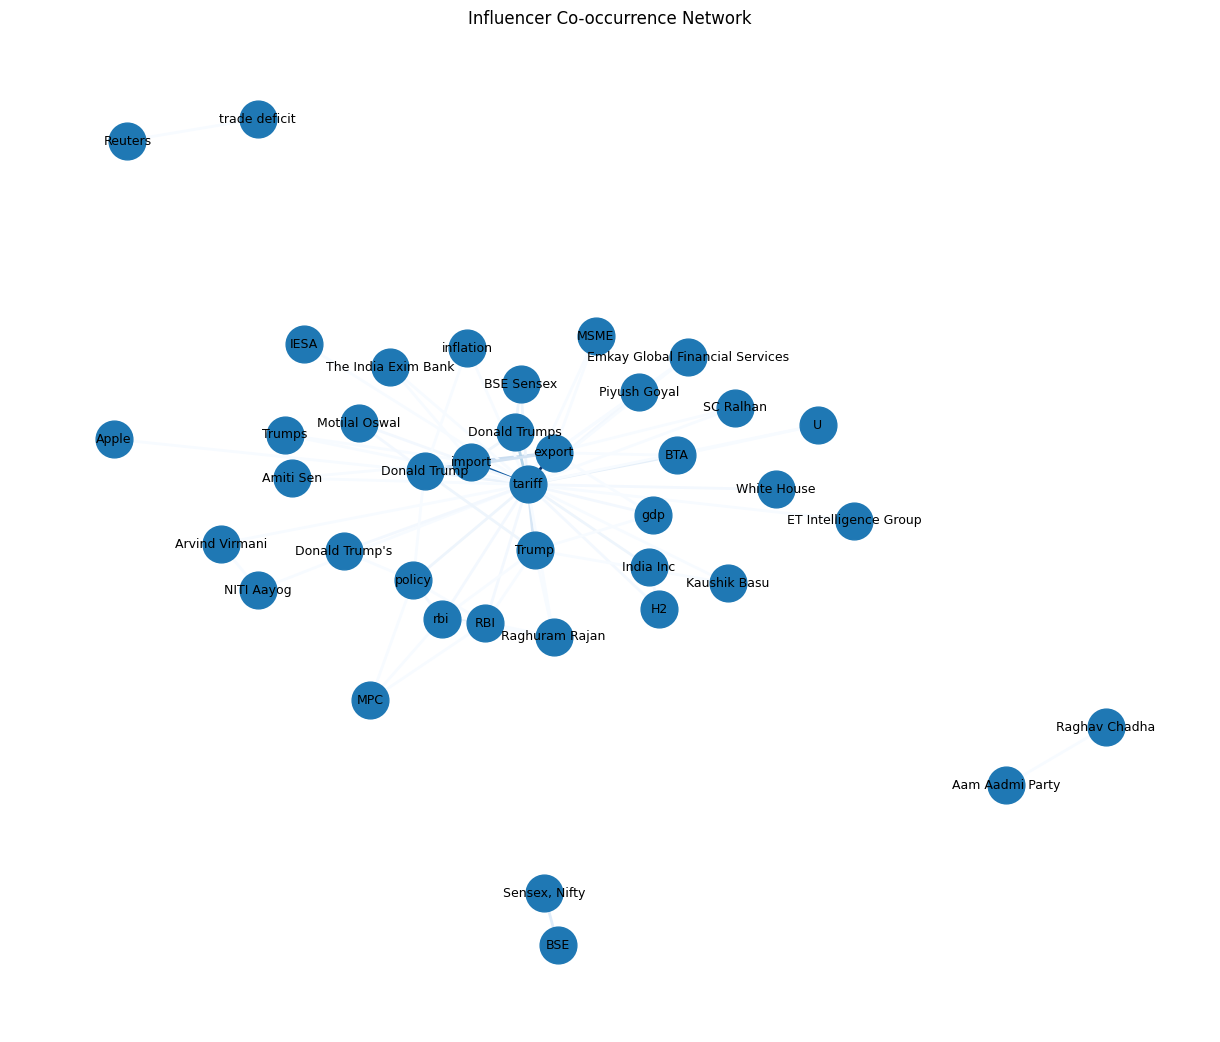

In [ ]:
# Install spaCy model (run once)
# !python -m spacy download en_core_web_sm

import pandas as pd
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from itertools import combinations

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Load your dataset
df = pd.read_csv("India_sector_news_articles.csv")

# Step 1: Filter articles that mention India in title, description, or content
df_filtered = df[
    df['title'].str.contains("India", case=False, na=False) |
    df['description'].str.contains("India", case=False, na=False) |
    df['content'].str.contains("India", case=False, na=False)
].copy()

# Step 2: Define cleaner NER filter
def is_valid_entity(ent):
    if len(ent.split()) > 4:
        return False
    blacklist = ["href", "window", "http", "cookie", "terms", "march", "april", "login"]
    if any(x in ent.lower() for x in blacklist):
        return False
    return ent[0].isupper()

# Step 3: Entity extraction
def extract_entities(text):
    doc = nlp(str(text))
    return [ent.text.strip() for ent in doc.ents if ent.label_ in ['PERSON', 'ORG'] and is_valid_entity(ent.text)]

df_filtered['entities'] = df_filtered['content'].apply(extract_entities)

# Step 4: Define economic keywords to treat as influencers
economic_terms = [
    "tariff", "inflation", "export", "import", "policy", "reform",
    "gst", "subsidy", "gdp", "trade deficit", "rupee", "rbi", "interest rate"
]

# Step 5: Match economic terms in content
def match_econ_terms(text):
    text = str(text).lower()
    return [term for term in economic_terms if term in text]

df_filtered['econ_terms'] = df_filtered['content'].apply(match_econ_terms)

# Step 6: Combine influencers
df_filtered['combined_influencers'] = df_filtered.apply(
    lambda row: row['entities'] + row['econ_terms'], axis=1
)

# Step 7: Count overall top influencers
all_influencers = [item for sublist in df_filtered['combined_influencers'] for item in sublist]
influencer_counts = Counter(all_influencers)
top_influencers = influencer_counts.most_common(15)

# Display top influencers
print("✅ Top Influencers in India-Focused Articles (NER + Economic Concepts):")
for name, count in top_influencers:
    print(f"{name}: {count} mentions")

# Optional: Save to CSV
df_filtered.to_csv("filtered_india_articles_with_influencers.csv", index=False)
print("\n✅ Saved cleaned dataset to 'filtered_india_articles_with_influencers.csv'")


# Step 8: Bar Plot of Top Influencers
top_names, top_counts = zip(*top_influencers)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(top_counts), y=list(top_names), palette="viridis")
plt.title("Top Influencers in India-Focused Articles")
plt.xlabel("Mentions")
plt.ylabel("Entity")
plt.tight_layout()
plt.show()

# Step 9: Co-occurrence Network of Influencers
# Build edges from co-occurring influencers
G = nx.Graph()
edges = []
for influencer_list in df_filtered['combined_influencers']:
    pairs = list(combinations(set(influencer_list), 2))
    edges.extend(pairs)

# Count co-occurrence weights
edge_weights = Counter(edges)
for (a, b), w in edge_weights.items():
    if w > 1:  # only keep edges with more than 1 co-occurrence
        G.add_edge(a, b, weight=w)

# Draw the graph
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5)
weights = [G[u][v]['weight'] for u,v in G.edges()]
nx.draw(G, pos, with_labels=True, node_size=700, font_size=9,
        edge_color=weights, width=2, edge_cmap=plt.cm.Blues)
plt.title("Influencer Co-occurrence Network")
plt.show()

STANCE DETECTION - GOVT. vs PUBLIC


In [ ]:
#FINE TUNING with labelled dataset


import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Load data
df = pd.read_csv("Final_Extended_Multilingual_Stance_Dataset.csv")  # adjust path if needed

# Train-test split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])

# Tokenizer and model
model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Dataset class
class StanceDataset(Dataset):
    def __init__(self, df):
        self.encodings = tokenizer(df["text"].tolist(), truncation=True, padding=True, max_length=128)
        self.labels = df["label"].tolist()

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()} | {"labels": torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

train_dataset = StanceDataset(train_df)
val_dataset = StanceDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# Training loop
for epoch in range(5):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"✅ Epoch {epoch+1} Loss: {total_loss:.4f}")

    # Evaluation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    print(f"📊 Epoch {epoch+1} Accuracy: {acc:.4f} | F1: {f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=["public", "government"]))


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1 Training: 100%|██████████| 42/42 [00:10<00:00,  3.92it/s]


✅ Epoch 1 Loss: 27.3801
📊 Epoch 1 Accuracy: 0.7952 | F1: 0.7922
              precision    recall  f1-score   support

      public       1.00      0.62      0.77        45
  government       0.69      1.00      0.82        38

    accuracy                           0.80        83
   macro avg       0.85      0.81      0.79        83
weighted avg       0.86      0.80      0.79        83



Epoch 2 Training: 100%|██████████| 42/42 [00:11<00:00,  3.71it/s]


✅ Epoch 2 Loss: 22.5476
📊 Epoch 2 Accuracy: 0.7349 | F1: 0.7260
              precision    recall  f1-score   support

      public       1.00      0.51      0.68        45
  government       0.63      1.00      0.78        38

    accuracy                           0.73        83
   macro avg       0.82      0.76      0.73        83
weighted avg       0.83      0.73      0.72        83



Epoch 3 Training: 100%|██████████| 42/42 [00:10<00:00,  4.02it/s]


✅ Epoch 3 Loss: 17.1493
📊 Epoch 3 Accuracy: 0.8434 | F1: 0.8433
              precision    recall  f1-score   support

      public       0.94      0.76      0.84        45
  government       0.77      0.95      0.85        38

    accuracy                           0.84        83
   macro avg       0.86      0.85      0.84        83
weighted avg       0.86      0.84      0.84        83



Epoch 4 Training: 100%|██████████| 42/42 [00:10<00:00,  4.09it/s]


✅ Epoch 4 Loss: 14.0004
📊 Epoch 4 Accuracy: 0.8675 | F1: 0.8672
              precision    recall  f1-score   support

      public       0.90      0.84      0.87        45
  government       0.83      0.89      0.86        38

    accuracy                           0.87        83
   macro avg       0.87      0.87      0.87        83
weighted avg       0.87      0.87      0.87        83



Epoch 5 Training: 100%|██████████| 42/42 [00:10<00:00,  4.14it/s]


✅ Epoch 5 Loss: 13.1655
📊 Epoch 5 Accuracy: 0.8795 | F1: 0.8794
              precision    recall  f1-score   support

      public       0.93      0.84      0.88        45
  government       0.83      0.92      0.88        38

    accuracy                           0.88        83
   macro avg       0.88      0.88      0.88        83
weighted avg       0.88      0.88      0.88        83



In [ ]:
model.save_pretrained("stance_xlmr_model")
tokenizer.save_pretrained("stance_xlmr_model")
print("✅ Fine-tuned stance model saved to folder: stance_xlmr_model")


✅ Fine-tuned stance model saved to folder: stance_xlmr_model


In [ ]:
# def predict_stance(text):
#     model.eval()
#     tokens = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)
#     with torch.no_grad():
#         output = model(**tokens)
#     pred = torch.argmax(output.logits, dim=1).item()
#     return "government" if pred == 1 else "public"
# def predict_stance_verbose(text):
#     model.eval()
#     tokens = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)
#     with torch.no_grad():
#         output = model(**tokens)
#     probs = torch.nn.functional.softmax(output.logits, dim=1)
#     pred = torch.argmax(probs).item()
#     label = "government" if pred == 1 else "public"
#     return label

# # Run it
# predict_stance_verbose("We are imposing an additional 145% tariffs on all Chinese imports")
def predict_stance_new(text, threshold=0.6):
    model.eval()
    tokens = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to(device)
    with torch.no_grad():
        output = model(**tokens)
    probs = torch.nn.functional.softmax(output.logits, dim=1)

    conf, pred = torch.max(probs, dim=1)
    conf = conf.item()
    pred = pred.item()

    # Apply threshold
    if conf < threshold:
        label = "uncertain"
    else:
        label = "government" if pred == 1 else "public"

    print(f"🔍 Prediction: {label}")
    print(f"   🟢 Public: {probs[0][0]:.2f} | 🟣 Government: {probs[0][1]:.2f} | ✅ Confidence: {conf:.2f}")
    return label


In [ ]:
print(predict_stance_new("China says 'Completely cancel reciprocal tariffs'"))


🔍 Prediction: government
   🟢 Public: 0.10 | 🟣 Government: 0.90 | ✅ Confidence: 0.90
government


In [ ]:
print(predict_stance_new("如果美方置两国和国际社会的利益于不顾，执意打关税战、贸易战，中方必将奉陪到底。晚安！"))

#it says china response will continue to the end.good night!

🔍 Prediction: public
   🟢 Public: 0.73 | 🟣 Government: 0.27 | ✅ Confidence: 0.73
public


In [ ]:
print(predict_stance_new("ट्रम्प की टैरिफ योजना में भारत को अमेरिका पर बढ़त हासिल है"))

🔍 Prediction: government
   🟢 Public: 0.06 | 🟣 Government: 0.94 | ✅ Confidence: 0.94
government


In [ ]:
print(predict_stance_new("UU le compra a México por que son las más baratas, incluso con el nuevo tariff."))

🔍 Prediction: public
   🟢 Public: 0.69 | 🟣 Government: 0.31 | ✅ Confidence: 0.69
public


SUMMARIZATION

In [ ]:
from transformers import PegasusTokenizer, PegasusForConditionalGeneration
import torch

# Load model and tokenizer
model_name = "google/pegasus-xsum"
tokenizer = PegasusTokenizer.from_pretrained(model_name)
model = PegasusForConditionalGeneration.from_pretrained(model_name)

# Policy-like text (replace with your Reddit or press release text)
text = """
An America First Trade Policy
On January 20, 2025, President Trump signed the Presidential Memorandum “America First Trade Policy”
laying out a plan to accomplish the transformational change necessary to reverse our country’s economic
decline. The Presidential Memorandum instructs USTR and other agencies to undertake rapid,
unprecedented work to put America First on trade.
5 Manufacturing Wage Premiums Have Diverged between Production and Nonproduction Workers (Fed. Reserve Bank of
Cleveland). 6 E. Moretti, "Local Multipliers" (Am. Econ. Review (May 2010)). 7 USDA Economic Research Service, Ag and Food Sectors and the Economy. 8 K. Malden, "Trends in U.S. Multinational Enterprise Activity in China, 2000-2017," at 12 (The U.S.-China Economic and
Security Review Commission (July 1, 2020). 9 C. Prestowitz, “The Betrayal of American Prosperity,” at 72. 10 R. Delfeld, "The Greater Gunbelt: The Next Defense Industrial Coalition" (American Affairs, Winter 2024).
THE PRESIDENT’S 2025 TRADE POLICY AGENDA | 3
Right away, the Presidential Memorandum strikes at the threat posed by the trade deficit by directing USTR
and other agencies to “investigate the causes of our country’s large and persistent annual trade deficits in
goods, as well as the economic and national security implications and risks resulting from such deficits.”
By reversing the flow of American wealth to foreign countries in the form of the trade deficit, the United
States can reclaim its technological, economic, and military edge.
The Presidential Memorandum further instructs the USTR to review our country’s economic relationship
with all nations in order to identify their unfair trade practices, including where trading partners engage in
non-reciprocal trade with the United States. By identifying, and acting against, such unfair and nonreciprocal practices, the United States can use its leverage to open new markets for U.S. exports and reshore the production that has been lost.
USTR has been empowered to chart a new course for any trade agreements to ensure they help raise wages
and grow our industrial base. USTR will review existing trade agreements to guarantee that those
agreements operate in the national interest. For instance, third countries should not be permitted to free
ride on our trade agreements with other trading partners. Alongside this review, USTR will commence the
statutorily required public consultation process of the United States-Mexico-Canada Agreement (USMCA)
in order to “assess the impact of the USMCA on American workers, farmers, ranchers, service providers,
and other businesses” in preparation for the mandated review of the agreement in July 2026. USTR will
also identify opportunities for bilateral or sector-specific plurilateral agreements that might be negotiated
to open new market access for U.S. exports and reorient the trading system to promote U.S.
competitiveness.
The Presidential Memorandum also addresses U.S. trade relations with the People’s Republic of China, the
single biggest source of our country’s large and persistent trade deficit and a unique economic challenge.
In his first term, President Trump negotiated a historic and enforceable Economic and Trade Agreement
Between the Government of the United States of America and the Government of the People’s Republic of
China (also known as the Phase One Agreement). However, there has been no action taken to enforce the
agreement where China has not lived up to its commitments. USTR will assess China’s compliance with
the Phase One Agreement.
The Phase One Agreement grew out of USTR’s investigation under Section 301 of the Trade Act of 1974
into China’s acts policies, and practices related to technology transfer, intellectual property (IP), and
innovation. Yet, technology and IP-intensive sectors are hardly the only ones that are threatened by China’s
non-market behavior. USTR will look broadly at the bilateral relationship to identify, and respond to,
additional unfair practices.
President Trump’s interest in addressing challenges in the relationship with China complements significant
interest by the U.S. Congress on the topic. Pursuant to the Presidential Memorandum, USTR will assess
the recent legislative proposals related to China’s Permanent Normal Trade Relation (PNTR) status and
“make recommendations regarding any proposed changes to such legislative proposals.”
Taken together, these workstreams signal a national commitment to continuing the America First approach
to trade developed in President Trump’s first term of office. By taking a strategic, yet vigorous, approach,
the United States can finally address the structural challenges distorting the global trading system in ways
that undermine U.S. competitiveness and course-correct for the short-sighted trade policy mistakes of the
past. """

# Tokenize input
batch = tokenizer(text, truncation=True, padding="longest", return_tensors="pt")

# Generate summary
translated = model.generate(**batch)
summary = tokenizer.decode(translated[0], skip_special_tokens=True)

print("📝 Policy Summary:\n", summary)


tokenizer_config.json:   0%|          | 0.00/87.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.52M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/259 [00:00<?, ?B/s]

📝 Policy Summary:
 The United States Trade Representative (USTR) has been empowered by the Presidential Memorandum “America First Trade Policy” to undertake rapid, unprecedented work to put America First on trade.


In [7]:
pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=6e969e92cd68174187bd3e21029d3c47ba26320806369c916da7dfe343717535
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score


Model Summarization Comparison

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



📝 Pegasus Summary:
President Donald Trump signed the United States-Mexico-Canada Agreement (U.S.MCA) on November 1, 2018.

📊 ROUGE: {'rouge1': np.float64(0.23076923076923078), 'rouge2': np.float64(0.12), 'rougeL': np.float64(0.23076923076923078), 'rougeLsum': np.float64(0.23076923076923078)}
🔹 BLEU: 0.0208


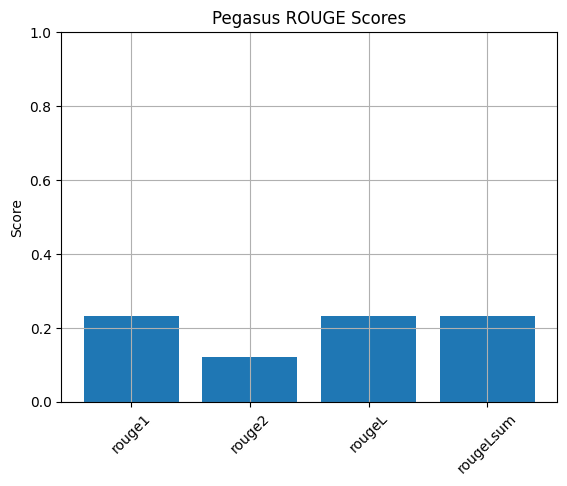


📝 mT5_XLSum Summary:
US President Donald Trump has signed a new trade policy, including the USTR.

📊 ROUGE: {'rouge1': np.float64(0.2916666666666667), 'rouge2': np.float64(0.04347826086956522), 'rougeL': np.float64(0.25000000000000006), 'rougeLsum': np.float64(0.25000000000000006)}
🔹 BLEU: 0.0056


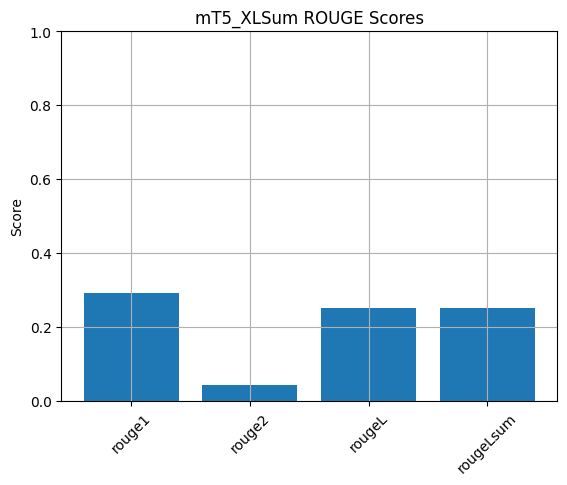


📌 Rationale Sentences (Pegasus):
✅ An America First Trade Policy
On January 20, 2025, President Trump signed the Presidential Memorandum “America First Trade Policy”
✅ The USMCA will be reviewed before 2026

📌 Rationale Sentences (mT5_XLSum):
✅ An America First Trade Policy
On January 20, 2025, President Trump signed the Presidential Memorandum “America First Trade Policy”


In [8]:
!pip install transformers sentence-transformers evaluate nltk -q

import torch
from transformers import (
    PegasusTokenizer, PegasusForConditionalGeneration,
    T5Tokenizer, MT5ForConditionalGeneration
)
from sentence_transformers import SentenceTransformer, util
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import evaluate
import matplotlib.pyplot as plt

# 📌 Load models
peg_tokenizer = PegasusTokenizer.from_pretrained("google/pegasus-xsum")
peg_model = PegasusForConditionalGeneration.from_pretrained("google/pegasus-xsum").eval()

mt5_tokenizer = T5Tokenizer.from_pretrained("csebuetnlp/mT5_multilingual_XLSum")
mt5_model = MT5ForConditionalGeneration.from_pretrained("csebuetnlp/mT5_multilingual_XLSum").eval()

embed_model = SentenceTransformer("all-MiniLM-L6-v2")
rouge = evaluate.load("rouge")

# 🔁 Helper functions
def summarize_model(text, tokenizer, model, prefix=""):
    input_text = prefix + text
    inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding="longest", max_length=512)
    with torch.no_grad():
        summary_ids = model.generate(inputs["input_ids"], max_length=60, min_length=20, do_sample=False)
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

def compute_bleu(reference, prediction):
    smoothie = SmoothingFunction().method4
    return round(sentence_bleu([reference.split()], prediction.split(), smoothing_function=smoothie), 4)

def highlight_rationale(input_text, summary):
    input_sents = [s.strip() for s in input_text.split('.') if len(s.strip()) > 20]
    summary_sents = [s.strip() for s in summary.split('.') if len(s.strip()) > 10]

    input_embeddings = embed_model.encode(input_sents, convert_to_tensor=True)
    summary_embeddings = embed_model.encode(summary_sents, convert_to_tensor=True)

    rationale_indices = set()
    for s_emb in summary_embeddings:
        sims = util.cos_sim(s_emb, input_embeddings)[0]
        top_match = torch.argmax(sims).item()
        rationale_indices.add(top_match)

    return [input_sents[i] for i in rationale_indices]

# ✍️ Input and reference
input_text = """An America First Trade Policy
On January 20, 2025, President Trump signed the Presidential Memorandum “America First Trade Policy”...
The USTR is directed to investigate trade deficits, unfair practices, and China’s noncompliance.
The USMCA will be reviewed before 2026.
The policy emphasizes U.S. competitiveness and economic security."""

reference_summary = """President Trump signed the 'America First Trade Policy' in 2025.
It directs USTR to investigate trade deficits, unfair practices, and review the USMCA.
The policy aims to promote U.S. competitiveness and correct previous failures."""

# 🔍 Run summarization
pegasus_sum = summarize_model(input_text, peg_tokenizer, peg_model)
mt5_sum = summarize_model(input_text, mt5_tokenizer, mt5_model)

# 📊 Evaluation
r_peg = rouge.compute(predictions=[pegasus_sum], references=[reference_summary])
r_mt5 = rouge.compute(predictions=[mt5_sum], references=[reference_summary])
b_peg = compute_bleu(reference_summary, pegasus_sum)
b_mt5 = compute_bleu(reference_summary, mt5_sum)

# 📌 Rationale tracking
rationale_peg = highlight_rationale(input_text, pegasus_sum)
rationale_mt5 = highlight_rationale(input_text, mt5_sum)

# 📈 Visualization
def show_summary_metrics(name, summary, rouge_scores, bleu_score):
    print(f"\n📝 {name} Summary:\n{summary}")
    print(f"\n📊 ROUGE: {rouge_scores}")
    print(f"🔹 BLEU: {bleu_score:.4f}")

    plt.bar(rouge_scores.keys(), [v for v in rouge_scores.values()])
    plt.title(f"{name} ROUGE Scores")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

# 🔍 Results
show_summary_metrics("Pegasus", pegasus_sum, r_peg, b_peg)
show_summary_metrics("mT5_XLSum", mt5_sum, r_mt5, b_mt5)

print("\n📌 Rationale Sentences (Pegasus):")
for r in rationale_peg: print("✅", r)

print("\n📌 Rationale Sentences (mT5_XLSum):")
for r in rationale_mt5: print("✅", r)


"Forecasts for current exchange rates and stock market performance."



"Chinese Currency Exchange Rates"



✅ RMSE: 0.0272
✅ MAE: 0.0220


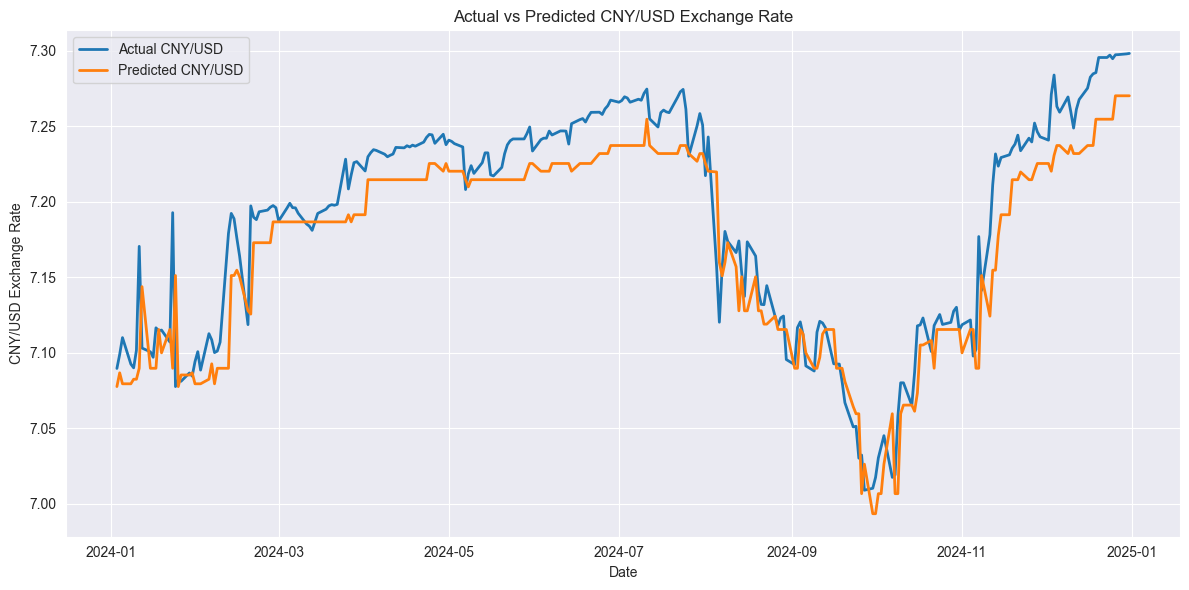

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# ---------------------------
# STEP 1: Load Data
# ---------------------------
china_news = pd.read_csv("china_news_with_sentiment.csv")
china_fx = pd.read_csv("Pre_CNY_USD_Exchange_Rate.csv")

# ---------------------------
# STEP 2: Clean & Process Data
# ---------------------------

# Process exchange rate
china_fx['Date'] = pd.to_datetime(china_fx['Date']).dt.date
china_fx['CNY_USD'] = pd.to_numeric(china_fx['CNY_USD'], errors='coerce')
china_fx = china_fx.dropna(subset=['CNY_USD'])

# Filter tariff-related news
china_news['text_lower'] = china_news['text'].str.lower()
tariff_keywords = ['tariff', 'duties', 'import tax', 'trade war', 'GSP', 'section 301', 'levies', 'sanctions']
tariff_news = china_news[china_news['text_lower'].str.contains('|'.join(tariff_keywords), na=False)].copy()
tariff_news['publish_date'] = pd.to_datetime(tariff_news['publish_date']).dt.date

# Aggregate sentiment & article count
agg_news = (
    tariff_news.groupby('publish_date')
    .agg(
        Tariff_Sentiment_Score=('sentiment_score', 'mean'),
        Tariff_Article_Count=('text', 'count')
    )
    .reset_index()
    .rename(columns={'publish_date': 'Date'})
)

# Merge with FX data
merged = pd.merge(china_fx, agg_news, on='Date', how='left')
merged['Tariff_Sentiment_Score'] = merged['Tariff_Sentiment_Score'].fillna(0)
merged['Tariff_Article_Count'] = merged['Tariff_Article_Count'].fillna(0)

# ---------------------------
# STEP 3: Feature Engineering
# ---------------------------
merged = merged.sort_values(by="Date")
merged['CNY_USD_Lag1'] = merged['CNY_USD'].shift(1)
merged['CNY_USD_Lag3'] = merged['CNY_USD'].shift(3)
merged['CNY_USD_MA7'] = merged['CNY_USD'].rolling(7).mean()
merged['Sentiment_MA3'] = merged['Tariff_Sentiment_Score'].rolling(3).mean()
merged['Article_Count_MA3'] = merged['Tariff_Article_Count'].rolling(3).mean()
merged = merged.dropna().reset_index(drop=True)

# ---------------------------
# STEP 4: Train-Test Split
# ---------------------------
features = [
    'CNY_USD_Lag1', 'CNY_USD_Lag3', 'CNY_USD_MA7',
    'Tariff_Sentiment_Score', 'Sentiment_MA3',
    'Tariff_Article_Count', 'Article_Count_MA3'
]
target = 'CNY_USD'

X = merged[features]
y = merged[target]
dates = pd.to_datetime(merged['Date'])

split_idx = int(len(merged) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_test = dates[split_idx:]

# ---------------------------
# STEP 5: Train XGBoost Model
# ---------------------------
model = XGBRegressor(n_estimators=30, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ---------------------------
# STEP 6: Evaluate & Visualize
# ---------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test.values, label='Actual CNY/USD', linewidth=2)
plt.plot(dates_test, y_pred, label='Predicted CNY/USD', linewidth=2)
plt.xlabel("Date")
plt.ylabel("CNY/USD Exchange Rate")
plt.title("Actual vs Predicted CNY/USD Exchange Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


"Chinese Stock Exchange Rates"



✅ RMSE: 69.9534
✅ MAE: 60.2752


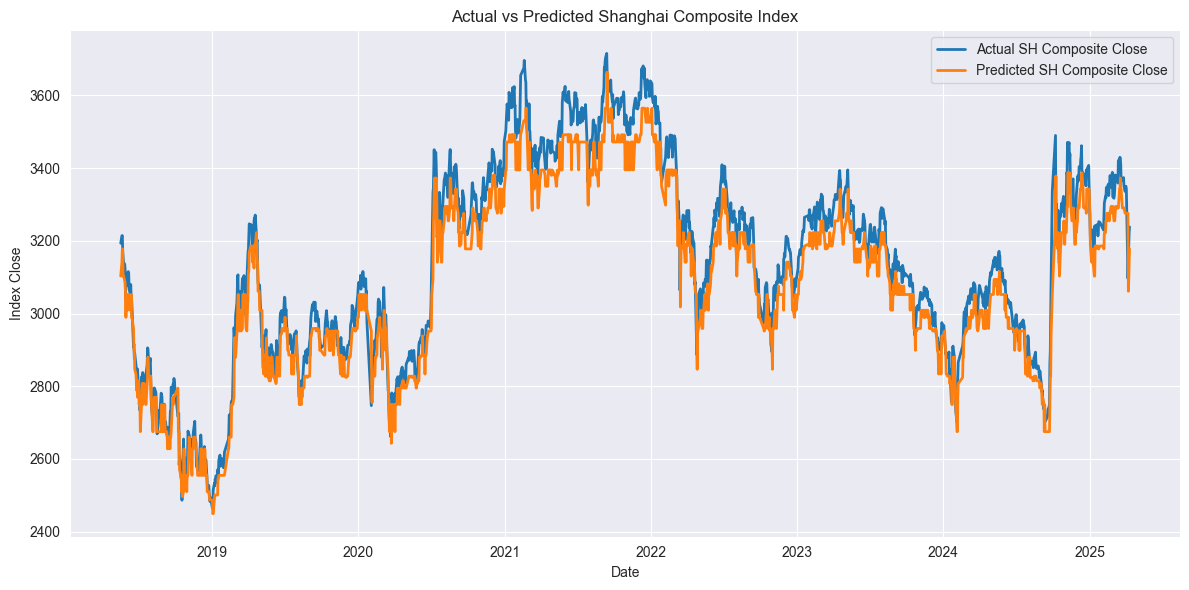

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------------------------
# Step 1: Load Data
# ---------------------------
shanghai_df = pd.read_csv("Shanghai_Composite_AKShare.csv")
china_news = pd.read_csv("china_news_with_sentiment.csv")

# ---------------------------
# Step 2: Preprocess Stock Data
# ---------------------------
shanghai_df['Date'] = pd.to_datetime(shanghai_df['date']).dt.date
shanghai_df = shanghai_df[['Date', 'open', 'high', 'low', 'close', 'volume']].rename(columns={'close': 'SH_Composite_Close'})

# ---------------------------
# Step 3: Preprocess News Data
# ---------------------------
china_news['text_lower'] = china_news['text'].str.lower()
tariff_keywords = ['tariff', 'duties', 'import tax', 'trade war', 'GSP', 'section 301', 'levies', 'sanctions']
tariff_news = china_news[china_news['text_lower'].str.contains('|'.join(tariff_keywords), na=False)].copy()
tariff_news['publish_date'] = pd.to_datetime(tariff_news['publish_date']).dt.date

agg_news = (
    tariff_news.groupby('publish_date')
    .agg(
        Tariff_Sentiment_Score=('sentiment_score', 'mean'),
        Tariff_Article_Count=('text', 'count')
    )
    .reset_index()
    .rename(columns={'publish_date': 'Date'})
)

# ---------------------------
# Step 4: Merge Stock + Sentiment
# ---------------------------
merged = pd.merge(shanghai_df, agg_news, on='Date', how='left')
merged['Tariff_Sentiment_Score'] = merged['Tariff_Sentiment_Score'].fillna(0)
merged['Tariff_Article_Count'] = merged['Tariff_Article_Count'].fillna(0)

# ---------------------------
# Step 5: Feature Engineering
# ---------------------------
merged = merged.sort_values(by="Date")
merged['Close_Lag1'] = merged['SH_Composite_Close'].shift(1)
merged['Close_Lag3'] = merged['SH_Composite_Close'].shift(3)
merged['Close_MA7'] = merged['SH_Composite_Close'].rolling(7).mean()
merged['Sentiment_MA3'] = merged['Tariff_Sentiment_Score'].rolling(3).mean()
merged['Article_Count_MA3'] = merged['Tariff_Article_Count'].rolling(3).mean()
merged = merged.dropna().reset_index(drop=True)

# ---------------------------
# Step 6: Define Features
# ---------------------------
features = [
    'Close_Lag1', 'Close_Lag3', 'Close_MA7',
    'Tariff_Sentiment_Score', 'Sentiment_MA3',
    'Tariff_Article_Count', 'Article_Count_MA3'
]
target = 'SH_Composite_Close'

X = merged[features]
y = merged[target]
dates = pd.to_datetime(merged['Date'])

# ---------------------------
# Step 7: Time-Based Split
# ---------------------------
split_idx = int(len(merged) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_test = dates[split_idx:]

# ---------------------------
# Step 8: Train XGBoost Model
# ---------------------------
model = XGBRegressor(n_estimators=30, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# ---------------------------
# Step 9: Predict & Evaluate
# ---------------------------
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")

# ---------------------------
# Step 10: Plot Predictions
# ---------------------------
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test.values, label='Actual SH Composite Close', linewidth=2)
plt.plot(dates_test, y_pred, label='Predicted SH Composite Close', linewidth=2)
plt.xlabel("Date")
plt.ylabel("Index Close")
plt.title("Actual vs Predicted Shanghai Composite Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


"Indian Currency Exhange Rate"

/var/folders/md/rpn4bbs93dv0hy3v0fw27rqw0000gn/T/ipykernel_40408/3504251330.py:30: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Return'] = df['INR_USD'].pct_change()


✅ RMSE: 1.7568
✅ MAE: 1.2211


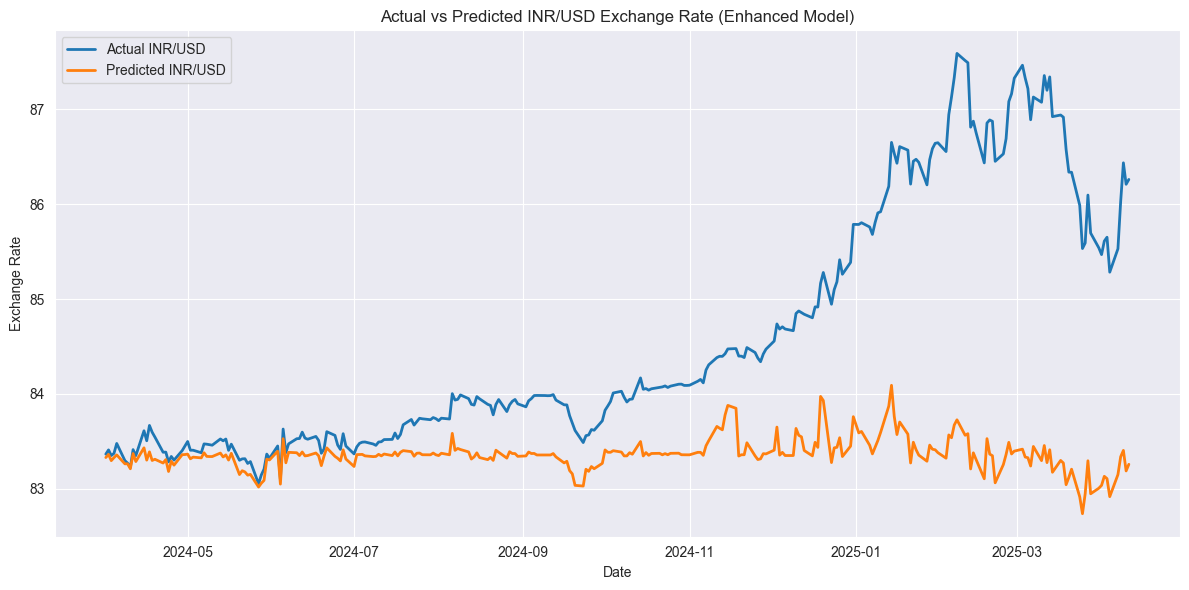

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from ta.momentum import RSIIndicator
from ta.trend import MACD

# ---------------------------
# Step 1: Load & Clean Data
# ---------------------------

df = pd.read_csv("merged_exchange_tariff_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['INR_USD'] = pd.to_numeric(df['INR_USD'], errors='coerce')
df = df.sort_values("Date")

# ---------------------------
# Step 2: Feature Engineering
# ---------------------------

# Lagged features & moving averages
df['INR_USD_Lag1'] = df['INR_USD'].shift(1)
df['INR_USD_Lag3'] = df['INR_USD'].shift(3)
df['INR_USD_MA7'] = df['INR_USD'].rolling(window=7).mean()
df['Tariff_Sentiment_MA3'] = df['Tariff_Sentiment_Score'].rolling(3).mean()
df['Tariff_Article_Count_MA3'] = df['Tariff_Article_Count'].rolling(3).mean()

# Technical indicators
df['Return'] = df['INR_USD'].pct_change()
df['Volatility'] = df['Return'].rolling(3).std()
df['RSI'] = RSIIndicator(close=df['INR_USD'], window=14).rsi()
macd = MACD(close=df['INR_USD'])
df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()

# Optional: Log transform of target
df['INR_USD_Log'] = np.log(df['INR_USD'])

# Drop NaNs
df = df.dropna().reset_index(drop=True)

# ---------------------------
# Step 3: Model Setup
# ---------------------------

features = [
    'INR_USD_Lag1', 'INR_USD_Lag3', 'INR_USD_MA7',
    'Tariff_Sentiment_Score', 'Tariff_Sentiment_MA3',
    'Tariff_Article_Count', 'Tariff_Article_Count_MA3',
    'Return', 'Volatility', 'RSI', 'MACD', 'MACD_signal'
]
target = 'INR_USD_Log'  # for better stability

X = df[features]
y = df[target]
dates = df['Date']

# ---------------------------
# Step 4: Time-Based Split
# ---------------------------

split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]
dates_test = dates[split_index:]

# ---------------------------
# Step 5: Train XGBoost Model
# ---------------------------

model = XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# Predict and reverse log-transform
y_pred_log = model.predict(X_test)
y_pred = np.exp(y_pred_log)
y_actual = np.exp(y_test)

# ---------------------------
# Step 6: Evaluation & Plot
# ---------------------------

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)

print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE: {mae:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_actual, label='Actual INR/USD', linewidth=2)
plt.plot(dates_test, y_pred, label='Predicted INR/USD', linewidth=2)
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.title("Actual vs Predicted INR/USD Exchange Rate (Enhanced Model)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Indian Stock Market Exchange Rate

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score

# Load enhanced dataset
df = pd.read_csv("enhanced_nifty_data_with_indicators.csv")

# Features
features = [
    'Close_Lag1', 'Close_Lag3', 'Close_MA7',
    'Tariff_Sentiment_Score', 'Sentiment_MA3',
    'Tariff_Article_Count', 'Article_Count_MA3',
    'Return', 'Volatility', 'RSI', 'MACD', 'MACD_signal'
]
X = df[features]
y = df['Direction']

# Train/test split
split_idx = int(len(df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Grid search setup
param_grid = {
    'n_estimators': [30, 50, 100],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Run the search
grid_search.fit(X_train_bal, y_train_bal)

# Best model
best_model = grid_search.best_estimator_
print("✅ Best Parameters:", grid_search.best_params_)

# Evaluate on test set
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"✅ Tuned Model Accuracy: {acc:.4f}")
print("📋 Classification Report:")
print(report)


Fitting 3 folds for each of 72 candidates, totalling 216 fits


/Users/karthiksharmamadugula/NLP/.venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:30:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/karthiksharmamadugula/NLP/.venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:30:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/karthiksharmamadugula/NLP/.venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:30:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/karthiksharmamadugula/NLP/.venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:30:21] WARNING: /Users/runner/work/xgboost/xgboost/src/lear

✅ Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 30, 'subsample': 1.0}
✅ Tuned Model Accuracy: 0.6714
📋 Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.36      0.47        28
           1       0.67      0.88      0.76        42

    accuracy                           0.67        70
   macro avg       0.67      0.62      0.61        70
weighted avg       0.67      0.67      0.64        70



/Users/karthiksharmamadugula/NLP/.venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [16:30:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 1000x600 with 0 Axes>

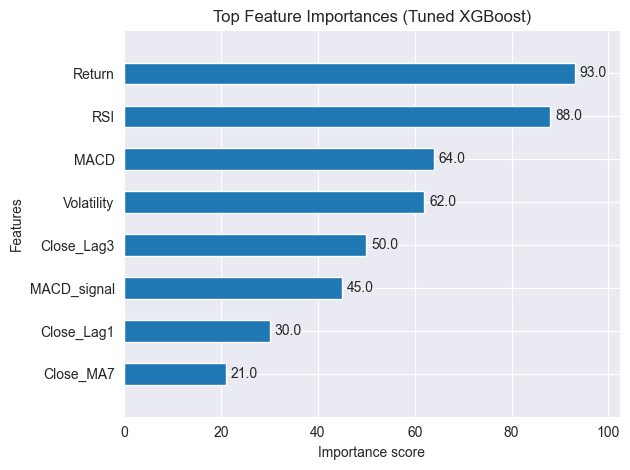

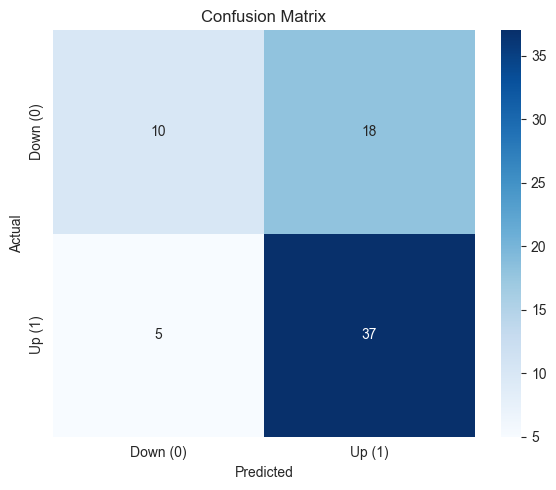

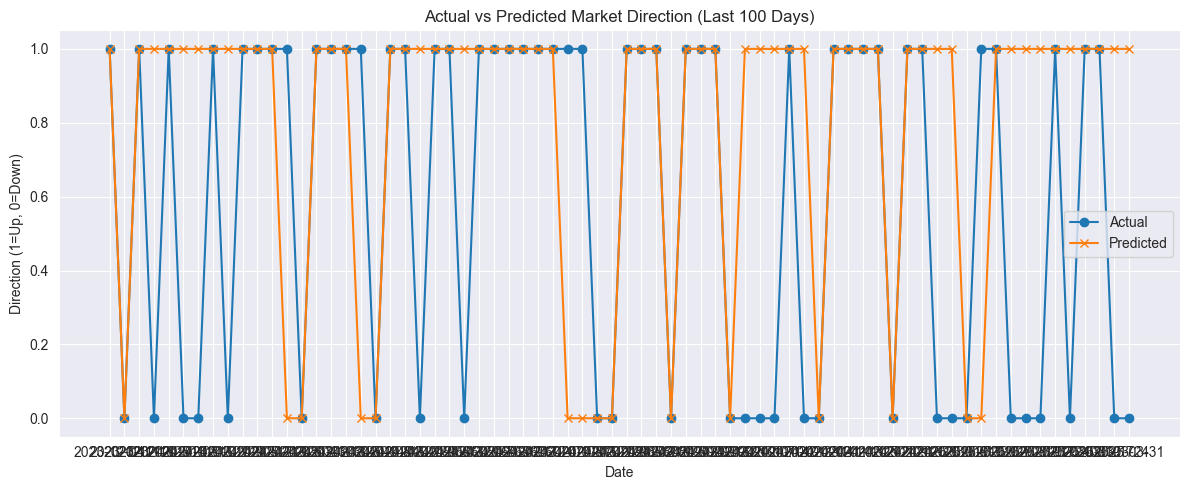

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# -----------------------------------------
# 🔍 Feature Importance Plot (XGBoost built-in)
# -----------------------------------------
from xgboost import plot_importance
plt.figure(figsize=(10, 6))
plot_importance(best_model, height=0.5, max_num_features=12)
plt.title("Top Feature Importances (Tuned XGBoost)")
plt.tight_layout()
plt.show()

# -----------------------------------------
# 📊 Confusion Matrix
# -----------------------------------------
cm = confusion_matrix(y_test, y_pred)
labels = ["Down (0)", "Up (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# -----------------------------------------
# 📈 Actual vs Predicted Direction Over Time
# -----------------------------------------
# Only show recent predictions (last 100 for clarity)
n = 100
recent_dates = df['Date'].iloc[-len(y_test):].tail(n)

plt.figure(figsize=(12, 5))
plt.plot(recent_dates, y_test.values[-n:], marker='o', label="Actual", linewidth=1.5)
plt.plot(recent_dates, y_pred[-n:], marker='x', label="Predicted", linewidth=1.5)
plt.title("Actual vs Predicted Market Direction (Last 100 Days)")
plt.xlabel("Date")
plt.ylabel("Direction (1=Up, 0=Down)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Mexican Currency Exchange Rate

✅ RMSE: 0.2319
✅ MAE : 0.1825


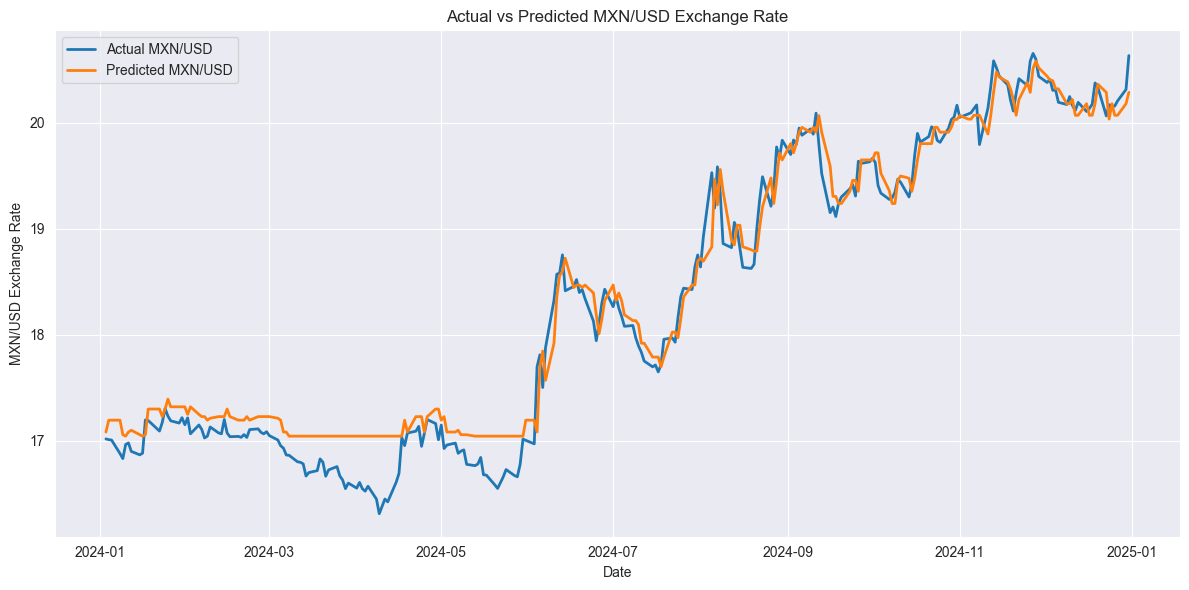

In [ ]:

# -----------------------------------
# Mexico MXN/USD Exchange Rate Model
# -----------------------------------
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# ---------------------------
# STEP 1: Load Data
# ---------------------------
mexico_news = pd.read_csv("mexico_news_with_sentiment.csv")
mexico_fx   = pd.read_csv("Pre_MXN_USD_Exchange_Rate.csv")

# ---------------------------
# STEP 2: Clean & Process Data
# ---------------------------
# Exchange rate
mexico_fx['Date']    = pd.to_datetime(mexico_fx['Date']).dt.date
mexico_fx['MXN_USD'] = pd.to_numeric(mexico_fx['MXN_USD'], errors='coerce')
mexico_fx            = mexico_fx.dropna(subset=['MXN_USD'])

# Tariff‐related news
mexico_news['text_lower'] = mexico_news['text'].str.lower()
tariff_kw = ['tariff', 'duties', 'import tax', 'trade war', 'levies', 'sanctions']
tariff_news = mexico_news[
    mexico_news['text_lower'].str.contains('|'.join(tariff_kw), na=False)
].copy()
tariff_news['publish_date'] = pd.to_datetime(tariff_news['publish_date']).dt.date

# Aggregate daily sentiment & counts
agg_news = (
    tariff_news.groupby('publish_date')
    .agg(
        Tariff_Sentiment_Score=('sentiment_score', 'mean'),
        Tariff_Article_Count=('text', 'count')
    )
    .reset_index()
    .rename(columns={'publish_date': 'Date'})
)

# Merge FX + news
merged = pd.merge(mexico_fx, agg_news, on='Date', how='left')
merged['Tariff_Sentiment_Score'] = merged['Tariff_Sentiment_Score'].fillna(0)
merged['Tariff_Article_Count']   = merged['Tariff_Article_Count'].fillna(0)

# ---------------------------
# STEP 3: Feature Engineering
# ---------------------------
merged = merged.sort_values('Date')
merged['MXN_USD_Lag1']   = merged['MXN_USD'].shift(1)
merged['MXN_USD_Lag3']   = merged['MXN_USD'].shift(3)
merged['MXN_USD_MA7']    = merged['MXN_USD'].rolling(7).mean()
merged['Sentiment_MA3']  = merged['Tariff_Sentiment_Score'].rolling(3).mean()
merged['Article_MA3']    = merged['Tariff_Article_Count'].rolling(3).mean()

# drop initial NaNs
merged = merged.dropna().reset_index(drop=True)

# ---------------------------
# STEP 4: Train‐Test Split
# ---------------------------
features = [
    'MXN_USD_Lag1', 'MXN_USD_Lag3', 'MXN_USD_MA7',
    'Tariff_Sentiment_Score', 'Sentiment_MA3',
    'Tariff_Article_Count', 'Article_MA3'
]
target = 'MXN_USD'

X = merged[features]
y = merged[target]
dates = pd.to_datetime(merged['Date'])

split = int(len(merged)*0.8)
X_train, X_test   = X[:split], X[split:]
y_train, y_test   = y[:split], y[split:]
dates_test        = dates[split:]

# ---------------------------
# STEP 5: Train XGBoost
# ---------------------------
model = XGBRegressor(
    n_estimators=30,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ---------------------------
# STEP 6: Evaluate & Plot
# ---------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE : {mae:.4f}")

plt.figure(figsize=(12,6))
plt.plot(dates_test, y_test.values,  label='Actual MXN/USD', linewidth=2)
plt.plot(dates_test, y_pred,         label='Predicted MXN/USD', linewidth=2)
plt.xlabel("Date")
plt.ylabel("MXN/USD Exchange Rate")
plt.title("Actual vs Predicted MXN/USD Exchange Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Mexican Stock Market Exchange Rate


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.6, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
✅ Tuned RMSE: 1537.0354
✅ Tuned MAE : 1241.7527


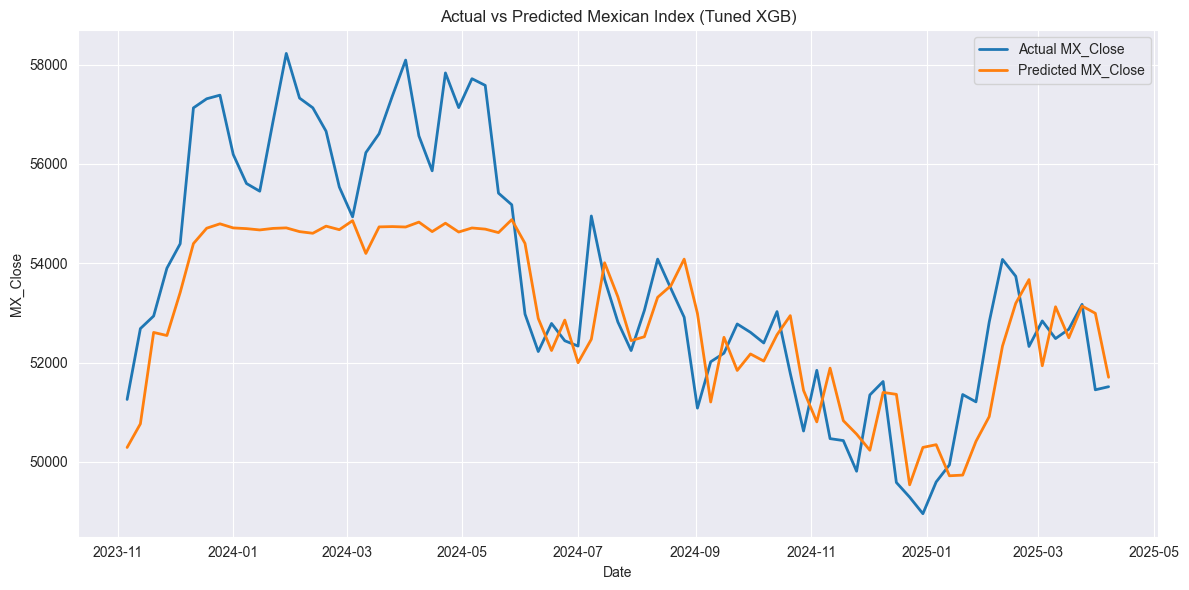

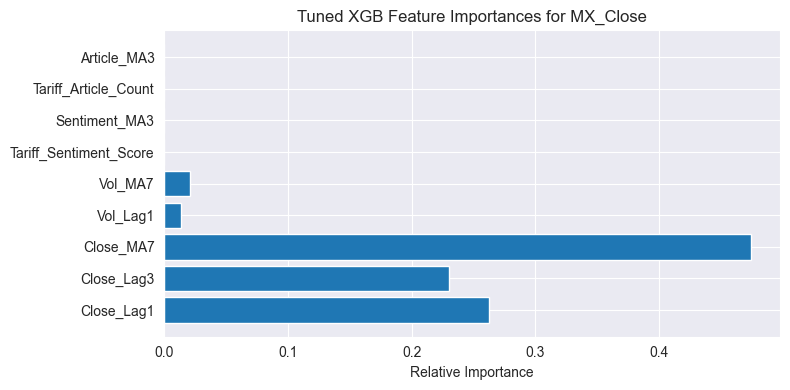

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# -----------------------------------
# Full Pipeline with Tuning & Extras
# -----------------------------------

# Step 1: Load Data
mex_df     = pd.read_csv("Mexican_data.csv")
mex_news   = pd.read_csv("mexico_news_with_sentiment.csv")

# (Optional) Load macro features if available:
# oil_df = pd.read_csv("WTI_price.csv")     # must have Date & WTI_Close
# vix_df = pd.read_csv("VIX.csv")           # must have Date & VIX_Close

# Step 2: Parse Dates
mex_df['Date'] = pd.to_datetime(mex_df['Date']).dt.date
mex_news['publish_date'] = pd.to_datetime(mex_news['publish_date']).dt.date
# if using oil/vix:
# oil_df['Date'] = pd.to_datetime(oil_df['Date']).dt.date
# vix_df['Date'] = pd.to_datetime(vix_df['Date']).dt.date

# Step 3: Coerce numeric columns
for col in ['Open','High','Low','Close','Volume']:
    mex_df[col] = pd.to_numeric(mex_df[col], errors='coerce')
mex_df = mex_df.dropna(subset=['Close']).reset_index(drop=True)

# Step 4: Rename
mex_df = mex_df.rename(columns={'Close':'MX_Close'})

# Step 5: Build tariff‐sentiment agg
tariff_kw = ['tariff','duties','import tax','trade war','levies','sanctions']
mex_news['text_lower'] = mex_news['text'].str.lower()
tariff_news = mex_news[
    mex_news['text_lower'].str.contains('|'.join(tariff_kw), na=False)
].copy()
agg_news = (
    tariff_news
    .groupby('publish_date')
    .agg(
        Tariff_Sentiment_Score=('sentiment_score','mean'),
        Tariff_Article_Count=('text','count')
    )
    .reset_index()
    .rename(columns={'publish_date':'Date'})
)

# Step 6: Merge everything
merged = (
    mex_df
    .merge(agg_news, on='Date', how='left')
    #.merge(oil_df[['Date','WTI_Close']], on='Date', how='left')
    #.merge(vix_df[['Date','VIX_Close']], on='Date', how='left')
)
merged[['Tariff_Sentiment_Score','Tariff_Article_Count']] = \
    merged[['Tariff_Sentiment_Score','Tariff_Article_Count']].fillna(0)

# Step 7: Feature engineering
merged = merged.sort_values('Date').reset_index(drop=True)

# price‐based
merged['Close_Lag1']  = merged['MX_Close'].shift(1)
merged['Close_Lag3']  = merged['MX_Close'].shift(3)
merged['Close_MA7']   = merged['MX_Close'].rolling(7).mean()

# volume‐based
merged['Vol_Lag1']    = merged['Volume'].shift(1)
merged['Vol_MA7']     = merged['Volume'].rolling(7).mean()

# sentiment rolling
merged['Sentiment_MA3']   = merged['Tariff_Sentiment_Score'].rolling(3).mean()
merged['Article_MA3']     = merged['Tariff_Article_Count'].rolling(3).mean()

# macro (if used)
# merged['WTI_Lag1']    = merged['WTI_Close'].shift(1)
# merged['VIX_Lag1']    = merged['VIX_Close'].shift(1)

merged = merged.dropna().reset_index(drop=True)

# Step 8: Prepare train/test
features = [
    'Close_Lag1','Close_Lag3','Close_MA7',
    'Vol_Lag1','Vol_MA7',
    'Tariff_Sentiment_Score','Sentiment_MA3',
    'Tariff_Article_Count','Article_MA3',
    # 'WTI_Lag1','VIX_Lag1'
]
X = merged[features]
y = merged['MX_Close']
dates = pd.to_datetime(merged['Date'])

split = int(len(merged)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test      = dates[split:]

# Step 9: Hyperparameter tuning with TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators':      [50, 100, 200],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [2, 3, 4],
    'subsample':         [0.6, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)
search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=42
)
search.fit(X_train, y_train)
best = search.best_estimator_
print("Best params:", search.best_params_)

# Step 10: Evaluate best model
y_pred = best.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f"✅ Tuned RMSE: {rmse:.4f}")
print(f"✅ Tuned MAE : {mae:.4f}")

#Step 11: Plot results
plt.figure(figsize=(12,6))
plt.plot(dates_test, y_test.values,  label='Actual MX_Close',    lw=2)
plt.plot(dates_test, y_pred,         label='Predicted MX_Close', lw=2)
plt.xlabel("Date")
plt.ylabel("MX_Close")
plt.title("Actual vs Predicted Mexican Index (Tuned XGB)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

importances = best.feature_importances_
plt.figure(figsize=(8,4))
plt.barh(features, importances)
plt.xlabel("Relative Importance")
plt.title("Tuned XGB Feature Importances for MX_Close")
plt.tight_layout()
plt.show()

Post-Tariff Economic Impact Analysis

In [ ]:
import pandas as pd

# === Step 1: Load All CSVs ===
cny_usd = pd.read_csv("CNY_USD_exchange.csv")
inr_usd = pd.read_csv("INR_USD_exchange.csv")
mxn_usd = pd.read_csv("MXN_USD_exchange.csv")
shanghai_stock = pd.read_csv("Shanghai_Composite_AKShare.csv")
mexican_stock = pd.read_csv("Mexican_data.csv")
nifty_data = pd.read_csv("NIFTY50_data.csv")  # India stock data

# Parse datetime
for df in [cny_usd, inr_usd, mxn_usd, mexican_stock, nifty_data]:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df.dropna(subset=['Date'], inplace=True)

shanghai_stock['date'] = pd.to_datetime(shanghai_stock['date'], errors='coerce')
shanghai_stock.dropna(subset=['date'], inplace=True)

# === Step 2: Load Sentiment-Labeled Data ===
china_sentiment = pd.read_csv("china_news_with_sentiment.csv", parse_dates=['publish_date'])
india_sentiment = pd.read_csv("india_news_with_sentiment.csv", parse_dates=['publish_date'])
mexico_sentiment = pd.read_csv("mexico_news_with_sentiment.csv", parse_dates=['publish_date'])


# Weekly sentiment grouping
def get_weekly_sentiment(df):
    df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)
    return df.groupby('week')['sentiment'].value_counts(normalize=True).unstack().fillna(0)


china_weekly_sent = get_weekly_sentiment(china_sentiment)
india_weekly_sent = get_weekly_sentiment(india_sentiment)
mexico_weekly_sent = get_weekly_sentiment(mexico_sentiment)

# === Step 3: Resample Weekly Indicators ===

# Convert close columns to numeric
for df in [cny_usd, inr_usd, mxn_usd, mexican_stock, nifty_data]:
    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

shanghai_stock['close'] = pd.to_numeric(shanghai_stock['close'], errors='coerce')

# --- CHINA ---
cny_usd.reset_index(drop=True, inplace=True)
cny_usd.set_index('Date', inplace=True)
cny_usd_weekly = cny_usd['Close'].resample('W').mean()

shanghai_stock.reset_index(drop=True, inplace=True)
shanghai_stock.set_index('date', inplace=True)
shanghai_weekly = shanghai_stock['close'].resample('W').mean()

# --- INDIA ---
inr_usd.reset_index(drop=True, inplace=True)
inr_usd.set_index('Date', inplace=True)
inr_usd_weekly = inr_usd['Close'].resample('W').mean()

nifty_data.reset_index(drop=True, inplace=True)
nifty_data.set_index('Date', inplace=True)
nifty_weekly = nifty_data['Close'].resample('W').mean()

# --- MEXICO ---
mxn_usd.reset_index(drop=True, inplace=True)
mxn_usd.set_index('Date', inplace=True)
mxn_usd_weekly = mxn_usd['Close'].resample('W').mean()

mexican_stock.reset_index(drop=True, inplace=True)
mexican_stock.set_index('Date', inplace=True)
mexico_stock_weekly = mexican_stock['Close'].resample('W').mean()


/var/folders/md/rpn4bbs93dv0hy3v0fw27rqw0000gn/T/ipykernel_40408/2657175283.py:27: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)
/var/folders/md/rpn4bbs93dv0hy3v0fw27rqw0000gn/T/ipykernel_40408/2657175283.py:27: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)
/var/folders/md/rpn4bbs93dv0hy3v0fw27rqw0000gn/T/ipykernel_40408/2657175283.py:27: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)


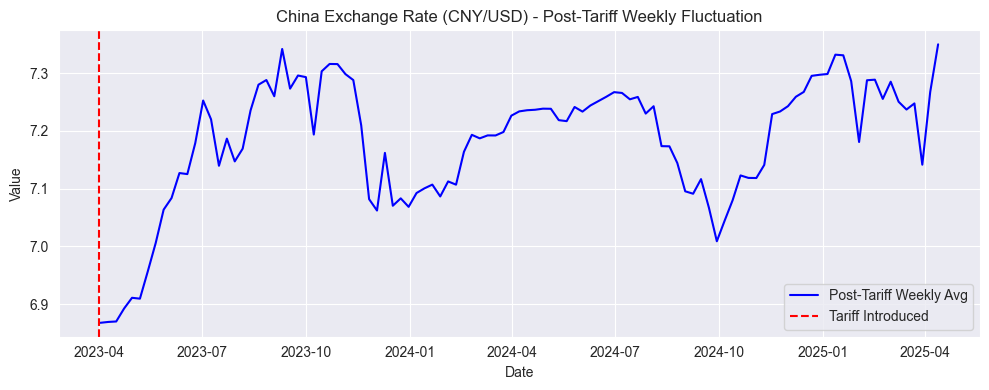

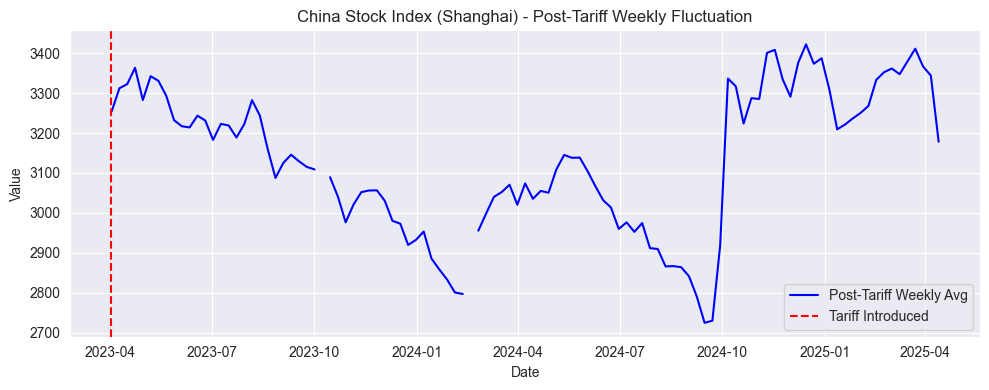

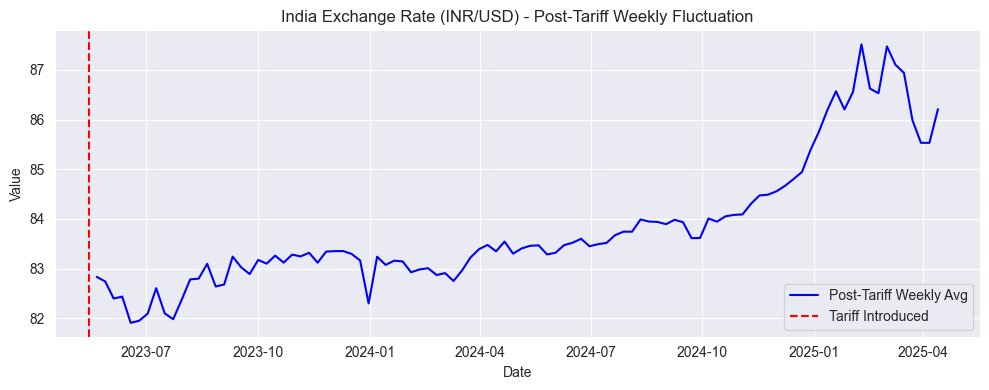

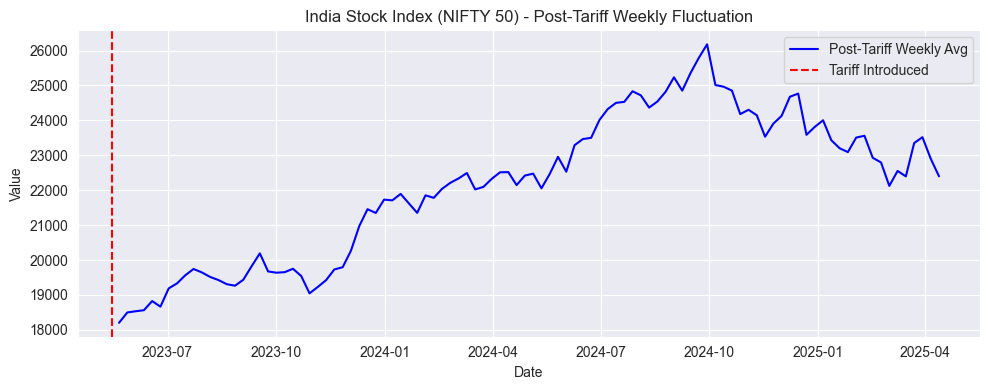

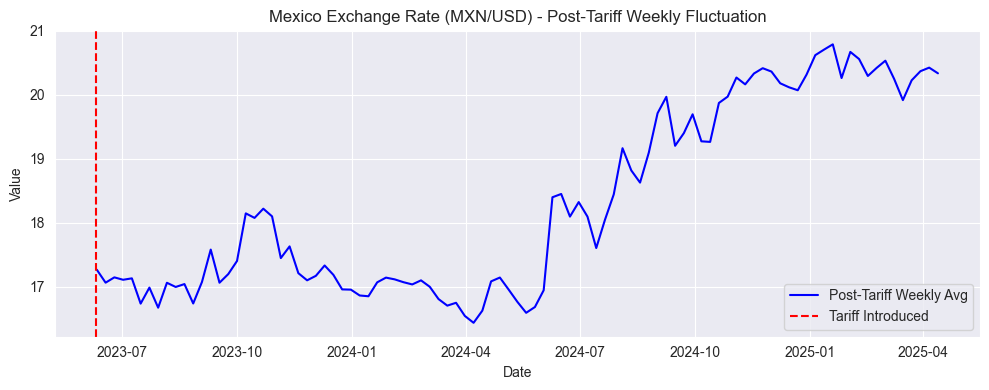

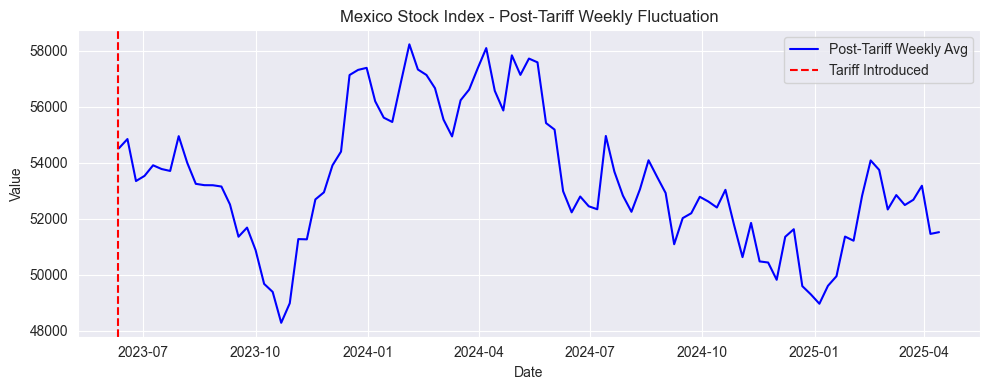

In [ ]:
import matplotlib.pyplot as plt

# Tariff introduction dates
tariff_dates = {
    "China": pd.to_datetime("2023-04-01"),
    "India": pd.to_datetime("2023-05-15"),
    "Mexico": pd.to_datetime("2023-06-10")
}

# Function to plot post-tariff trends
def plot_fluctuations_post_tariff(series, title, tariff_date):
    filtered_series = series[series.index >= tariff_date]
    plt.figure(figsize=(10, 4))
    plt.plot(filtered_series.index, filtered_series.values, label='Post-Tariff Weekly Avg', color='blue')
    plt.axvline(tariff_date, color='red', linestyle='--', label='Tariff Introduced')
    plt.title(f'{title} - Post-Tariff Weekly Fluctuation')
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === Plot for each metric and country ===

# 🇨🇳 China
plot_fluctuations_post_tariff(cny_usd_weekly, "China Exchange Rate (CNY/USD)", tariff_dates["China"])
plot_fluctuations_post_tariff(shanghai_weekly, "China Stock Index (Shanghai)", tariff_dates["China"])

# 🇮🇳 India
plot_fluctuations_post_tariff(inr_usd_weekly, "India Exchange Rate (INR/USD)", tariff_dates["India"])
plot_fluctuations_post_tariff(nifty_weekly, "India Stock Index (NIFTY 50)", tariff_dates["India"])

# 🇲🇽 Mexico
plot_fluctuations_post_tariff(mxn_usd_weekly, "Mexico Exchange Rate (MXN/USD)", tariff_dates["Mexico"])
plot_fluctuations_post_tariff(mexico_stock_weekly, "Mexico Stock Index", tariff_dates["Mexico"])


Sentiment Comparison Heatmap
Positive sentiment

/var/folders/md/rpn4bbs93dv0hy3v0fw27rqw0000gn/T/ipykernel_40408/2672424745.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)
/var/folders/md/rpn4bbs93dv0hy3v0fw27rqw0000gn/T/ipykernel_40408/2672424745.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)
/var/folders/md/rpn4bbs93dv0hy3v0fw27rqw0000gn/T/ipykernel_40408/2672424745.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)


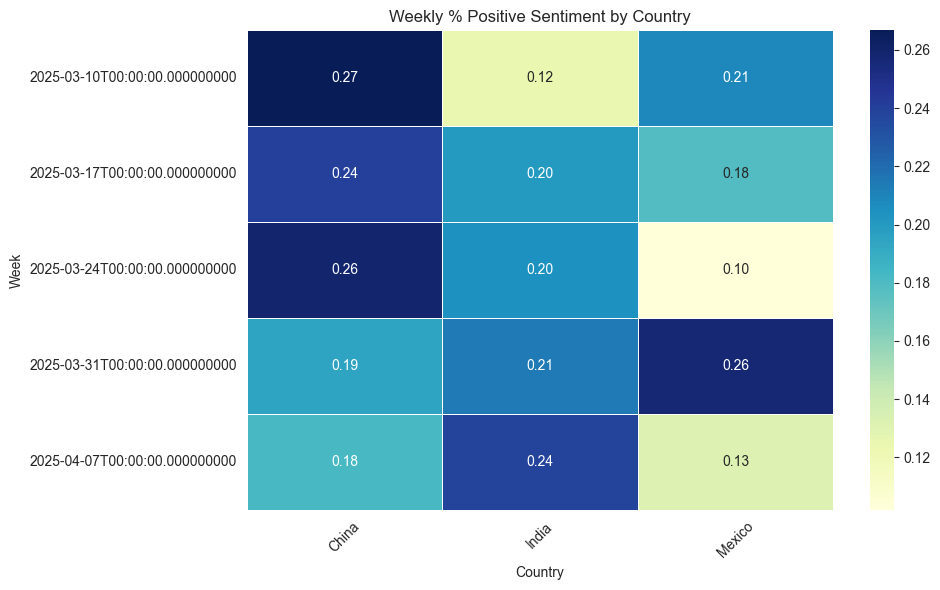

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load sentiment-labeled CSVs
china_sentiment = pd.read_csv("china_news_with_sentiment.csv", parse_dates=["publish_date"])
india_sentiment = pd.read_csv("india_news_with_sentiment.csv", parse_dates=["publish_date"])
mexico_sentiment = pd.read_csv("mexico_news_with_sentiment.csv", parse_dates=["publish_date"])

# Step 2: Group sentiment weekly by country
def process_weekly_sentiment(df, country_name):
    df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)
    sentiment_dist = df.groupby(['week'])['sentiment'].value_counts(normalize=True).unstack().fillna(0)
    sentiment_dist['Country'] = country_name
    return sentiment_dist.reset_index()

china_weekly = process_weekly_sentiment(china_sentiment, 'China')
india_weekly = process_weekly_sentiment(india_sentiment, 'India')
mexico_weekly = process_weekly_sentiment(mexico_sentiment, 'Mexico')

# Step 3: Combine all
sentiment_combined = pd.concat([china_weekly, india_weekly, mexico_weekly])

# Step 4: Pivot for heatmap (positive sentiment only)
heatmap_df = sentiment_combined.pivot(index='week', columns='Country', values='positive')

# Step 5: Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title("Weekly % Positive Sentiment by Country")
plt.xlabel("Country")
plt.ylabel("Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Sentiment Comparison Heatmap
Nuetural sentiment

/var/folders/md/rpn4bbs93dv0hy3v0fw27rqw0000gn/T/ipykernel_40408/3593045363.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)
/var/folders/md/rpn4bbs93dv0hy3v0fw27rqw0000gn/T/ipykernel_40408/3593045363.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)
/var/folders/md/rpn4bbs93dv0hy3v0fw27rqw0000gn/T/ipykernel_40408/3593045363.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)


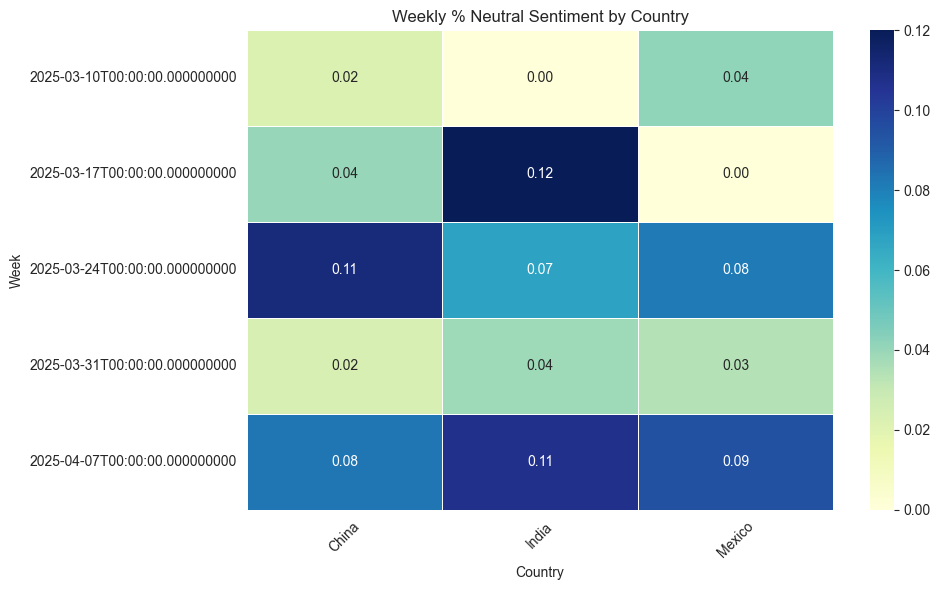

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load sentiment-labeled CSVs
china_sentiment = pd.read_csv("china_news_with_sentiment.csv", parse_dates=["publish_date"])
india_sentiment = pd.read_csv("india_news_with_sentiment.csv", parse_dates=["publish_date"])
mexico_sentiment = pd.read_csv("mexico_news_with_sentiment.csv", parse_dates=["publish_date"])

# Step 2: Group sentiment weekly by country
def process_weekly_sentiment(df, country_name):
    df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)
    sentiment_dist = df.groupby(['week'])['sentiment'].value_counts(normalize=True).unstack().fillna(0)
    sentiment_dist['Country'] = country_name
    return sentiment_dist.reset_index()

china_weekly = process_weekly_sentiment(china_sentiment, 'China')
india_weekly = process_weekly_sentiment(india_sentiment, 'India')
mexico_weekly = process_weekly_sentiment(mexico_sentiment, 'Mexico')

# Step 3: Combine all
sentiment_combined = pd.concat([china_weekly, india_weekly, mexico_weekly])

# Step 4: Pivot for heatmap (positive sentiment only)
heatmap_df = sentiment_combined.pivot(index='week', columns='Country', values='neutral')

# Step 5: Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title("Weekly % Neutral Sentiment by Country")
plt.xlabel("Country")
plt.ylabel("Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Sentiment Comparison Heatmap
Negative sentiment

/var/folders/md/rpn4bbs93dv0hy3v0fw27rqw0000gn/T/ipykernel_40408/2071289636.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)
/var/folders/md/rpn4bbs93dv0hy3v0fw27rqw0000gn/T/ipykernel_40408/2071289636.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)
/var/folders/md/rpn4bbs93dv0hy3v0fw27rqw0000gn/T/ipykernel_40408/2071289636.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)


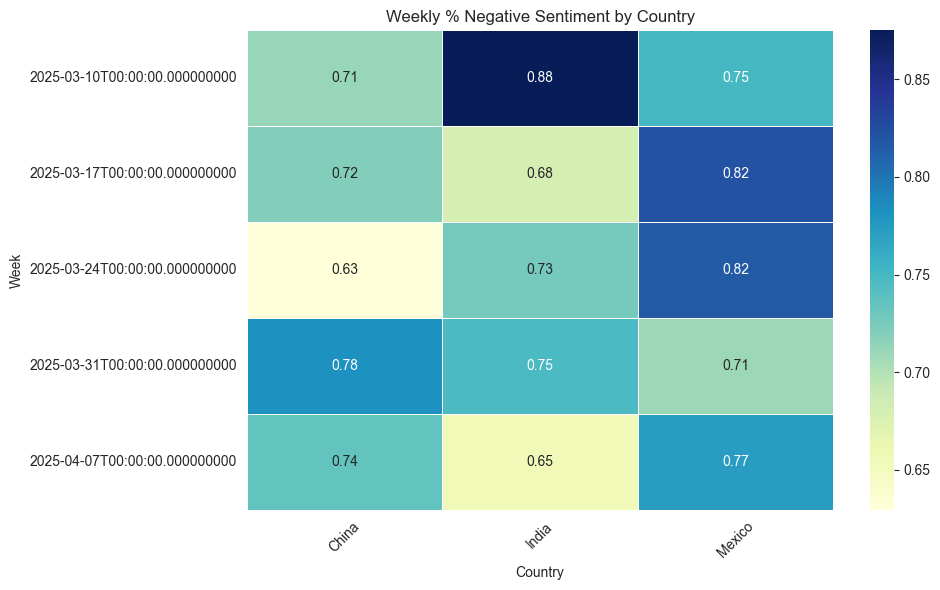

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load sentiment-labeled CSVs
china_sentiment = pd.read_csv("china_news_with_sentiment.csv", parse_dates=["publish_date"])
india_sentiment = pd.read_csv("india_news_with_sentiment.csv", parse_dates=["publish_date"])
mexico_sentiment = pd.read_csv("mexico_news_with_sentiment.csv", parse_dates=["publish_date"])

# Step 2: Group sentiment weekly by country
def process_weekly_sentiment(df, country_name):
    df['week'] = df['publish_date'].dt.to_period('W').apply(lambda r: r.start_time)
    sentiment_dist = df.groupby(['week'])['sentiment'].value_counts(normalize=True).unstack().fillna(0)
    sentiment_dist['Country'] = country_name
    return sentiment_dist.reset_index()

china_weekly = process_weekly_sentiment(china_sentiment, 'China')
india_weekly = process_weekly_sentiment(india_sentiment, 'India')
mexico_weekly = process_weekly_sentiment(mexico_sentiment, 'Mexico')

# Step 3: Combine all
sentiment_combined = pd.concat([china_weekly, india_weekly, mexico_weekly])

# Step 4: Pivot for heatmap (positive sentiment only)
heatmap_df = sentiment_combined.pivot(index='week', columns='Country', values='negative')

# Step 5: Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title("Weekly % Negative Sentiment by Country")
plt.xlabel("Country")
plt.ylabel("Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Data Scraping

Indian Currency Excahnge


In [ ]:
import yfinance as yf
import pandas as pd

# Download daily INR/USD exchange rate data from Jan 1, 2024 to today
ticker = 'INR=X'
data = yf.download(ticker, start='2024-01-01', end=None, interval='1d')  # 'end=None' = today

# Reset index to expose 'Date'
data.reset_index(inplace=True)

# Debug: show column names
print("📅 Columns:", list(data.columns))

# Ensure 'Date' and 'Close' exist
if 'Date' in data.columns and 'Close' in data.columns:
    # Keep and clean relevant columns
    data = data[['Date', 'Close']].dropna()
    data['Date'] = pd.to_datetime(data['Date'])
    data['Close'] = data['Close'].round(4)

    # Save to CSV
    data.to_csv("INR_USD_daily_2024_present.csv", index=False)
    print("✅ Saved daily INR/USD exchange data to 'INR_USD_daily_2024_present.csv'")
else:
    print("❌ Required columns not found. Sample data:")
    print(data.head())


Mexican Currency Exchange

In [ ]:
import yfinance as yf
import pandas as pd

# Download daily MXN/USD exchange rate data from Jan 1, 2024 to today
ticker = 'MXN=X'
data = yf.download(ticker, start='2024-01-01', end=None, interval='1d')  # end=None = today

# Reset index to expose 'Date'
data.reset_index(inplace=True)

# Debug: show column names
print("📅 Columns:", list(data.columns))

# Ensure 'Date' and 'Close' exist
if 'Date' in data.columns and 'Close' in data.columns:
    # Keep and clean relevant columns
    data = data[['Date', 'Close']].dropna()
    data['Date'] = pd.to_datetime(data['Date'])
    data['Close'] = data['Close'].round(4)

    # Save to CSV
    data.to_csv("MXN_USD_daily_2024_present.csv", index=False)
    print("✅ Saved daily MXN/USD exchange data to 'MXN_USD_daily_2024_present.csv'")
else:
    print("❌ Required columns not found. Sample data:")
    print(data.head())


Chinees Currency

In [ ]:
ticker = 'CNY=X'  # USD to Mexican Pesos
data = yf.download(ticker, start='2018-01-01', end='2025-04-10', interval='1wk')

# Save data
data.reset_index(inplace=True)
data.to_csv('CNY_USD_exchange.csv', index=False)
print("Saved CNY/USD exchange data to INR_USD_exchange.csv")

# Repeat this with other tickers:
# - MXN=X for Mexican Peso
# - CNY=X for Chinese Yuan
# - ^MXX for Mexican Stock Index
# - ^SSEC for Shanghai Composite Index

Indian Stock Exchange Data

In [ ]:
import yfinance as yf
import pandas as pd

# NIFTY 50 Index
ticker = '^NSEI'
data = yf.download(ticker, start='2018-01-01', end='2025-04-10', interval='1wk')

data.reset_index(inplace=True)
data.to_csv('NIFTY50_data.csv', index=False)
print("Saved NIFTY 50 data to NIFTY50_data.csv")

Mexican Stock Exchange Data

In [ ]:
import yfinance as yf
import pandas as pd

# NIFTY 50 Index
ticker = '^MXX'
data = yf.download(ticker, start='2018-01-01', end='2025-04-10', interval='1wk')

data.reset_index(inplace=True)
data.to_csv('Mexican_data.csv', index=False)
print("Saved mexican data to Mexican_data.csv")

Chinees Stock Exchange Data

In [ ]:
import akshare as ak
import pandas as pd

# Fetch Shanghai Composite Index (SSEC) historical data
df = ak.stock_zh_index_daily(symbol="sh000001")  # SSEC's symbol in AKShare

# Save to CSV
df.to_csv('Shanghai_Composite_AKShare.csv', index=False)
print("Successfully saved Shanghai Composite data using AKShare")

News Articles Data

In [ ]:
import requests
import pandas as pd

# Replace 'YOUR_API_KEY' with the API key you got from NewsAPI
API_KEY = '3c4c71b4358d49a0a9967b0d7758820d'
BASE_URL = "https://newsapi.org/v2/everything?"

# Query Parameters
params = {
    'language': 'en',  # English language news
    'pageSize': 100,  # Number of articles to fetch
    'apiKey': API_KEY  # Your API key
}

# Queries for each country
queries = [
    ('US tariffs impact India', 'India'),
    ('US tariffs impact Mexico', 'Mexico'),
    ('US tariffs impact China', 'China')
]

# Fetch articles for each query (country)
for query, country in queries:
    params['q'] = query  # Set the query for the current country
    articles = []  # List to store articles for the country
    total_articles = 0

    # Loop through pages to collect articles (up to 5 pages)
    for page in range(1, 6):  # Retrieve 5 pages of results
        params['page'] = page
        response = requests.get(BASE_URL, params=params)

        if response.status_code == 200:
            data = response.json()
            total_articles += data['totalResults']
            print(f"Total articles found for {country}: {total_articles}")

            # Extract articles from the response
            for article in data['articles']:
                articles.append({
                    'country': country,
                    'title': article['title'],
                    'description': article['description'],
                    'text': article['content'],
                    'publish_date': article['publishedAt'],
                    'url': article['url']
                })
        else:
            print(f"Error fetching data for {country}: {response.status_code}")
            break  # Exit the loop if we hit an error

    # Convert the list of articles into a DataFrame
    df_news = pd.DataFrame(articles)

    # Save the articles for the current country to a CSV file
    if not df_news.empty:
        file_path = f'/Users/karthiksharmamadugula/DL/DL_Assingment/NLP/{country}_news_articles.csv'
        df_news.to_csv(file_path, index=False)
        print(f"Saved {len(df_news)} articles for {country} to {file_path}")
    else:
        print(f"No articles found for {country}")


Sector wise effected data

In [ ]:
import requests
import pandas as pd

# Replace 'YOUR_API_KEY' with the API key you got from NewsAPI
API_KEY = '3c4c71b4358d49a0a9967b0d7758820d'  # Replace with your actual API key
BASE_URL = "https://newsapi.org/v2/everything?"

# Define the sectors and their keywords for the countries
sectors = {
    "China": ["machinery", "electronics", "automotive", "steel", "textiles"],
    "Mexico": ["machinery", "automotive", "electronics", "agriculture", "manufacturing"],
    "India": ["machinery", "electronics", "pharmaceuticals", "automotive", "agriculture"]
}

# Function to get news articles based on sectors
def fetch_news(country, sector_keywords):
    articles = []
    for keyword in sector_keywords:
        params = {
            'q': f'US tariffs impact {keyword} exports from {country}',  # Focus on sector and country
            'language': 'en',  # English language news
            'pageSize': 100,  # Number of articles to fetch
            'apiKey': API_KEY  # Your API key
        }

        # Fetch news articles using NewsAPI
        response = requests.get(BASE_URL, params=params)

        if response.status_code == 200:
            data = response.json()
            # Extract relevant information
            for article in data['articles']:
                articles.append({
                    'country': country,
                    'sector': keyword,
                    'title': article['title'],
                    'description': article['description'],
                    'content': article['content'],
                    'publish_date': article['publishedAt'],
                    'url': article['url']
                })
        else:
            print(f"Error fetching data for {country} sector {keyword}: {response.status_code}")

    return articles

# Fetch data for each country and sector
all_articles = []
for country, sector_keywords in sectors.items():
    print(f"Fetching news for {country}...")
    country_articles = fetch_news(country, sector_keywords)
    all_articles.extend(country_articles)

# Convert the list of articles into a DataFrame
df_news = pd.DataFrame(all_articles)

# Save separate CSV files for each country
for country in ['India', 'Mexico', 'China']:
    country_df = df_news[df_news['country'] == country]
    if not country_df.empty:
        country_df.to_csv(f'{country}_sector_news_articles.csv', index=False)
        print(f"Saved {len(country_df)} articles for {country} to {country}_sector_news_articles.csv")


Reddit scraper

In [ ]:
import praw
import pandas as pd
from datetime import datetime
from langdetect import detect
from googletrans import Translator
import time

# Reddit API Setup
reddit = praw.Reddit(
    client_id="",
    client_secret="",
    user_agent=""
)

translator = Translator()

# Translation with retry wrapper
def translate_with_retry(text, src_lang, max_retries=3):
    retries = 0
    while retries < max_retries:
        try:
            translated = translator.translate(text, src=src_lang, dest="en").text
            return translated
        except Exception as e:
            retries += 1
            time.sleep(1.5)  # Wait before retrying
    return text  # Return original if translation fails

# Fetch posts function
def fetch_subreddit_posts(subreddit_name, queries, start_date, end_date, limit=250):
    subreddit = reddit.subreddit(subreddit_name)
    posts = []

    for query in queries:
        for submission in subreddit.search(query, limit=limit, time_filter="all"):
            post_date = datetime.fromtimestamp(submission.created_utc)
            if start_date <= post_date <= end_date:
                post_text = f"{submission.title}\n{submission.selftext}".strip()
                if post_text:
                    try:
                        lang = detect(post_text)
                        if lang != "en":
                            translated = translate_with_retry(post_text, src_lang=lang)
                        else:
                            translated = post_text
                    except Exception as e:
                        lang = "unknown"
                        translated = post_text

                    posts.append({
                        "date": post_date,
                        "text": post_text,
                        "translated_text": translated,
                        "language": lang,
                        "query": query,
                        "subreddit": subreddit_name
                    })

    return posts

# Main function
def main():
    queries_default = ["tariff", "trade"]
    subreddits = {
        "geopolitics": queries_default,
        "economics": queries_default,
        "politics": queries_default,
        "AskEconomics": queries_default,
        "mexico": ["arancel", "comercio", "política", "aranceles"],
        "india": ["tariff", "trade"],
        "china": ["tariff","trade"]

    }

    start_date = datetime(2024, 11, 1)
    end_date = datetime(2025, 4, 12)

    all_posts = []
    for subreddit, queries in subreddits.items():
        posts = fetch_subreddit_posts(subreddit, queries, start_date, end_date)
        all_posts.extend(posts)

    df = pd.DataFrame(all_posts)
    df.sort_values(by="date", inplace=True)
    df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")

    df.to_csv("reddit_tariffs_multilingual_translated.csv", index=False)
    print(f"✅ Saved {len(df)} multilingual posts to 'reddit_tariffs_multilingual_translated.csv'")

if __name__ == "__main__":
    main()
